# 🏦 CAPSTONE PROJECT: BANK CUSTOMER CHURN PREDICTION
---

## Project Overview

You have been appointed as the **Lead Data Scientist** at a multinational retail bank. The bank has observed a worrying trend — a growing number of customers are closing their accounts and moving to competitors. Each churned customer represents a direct revenue loss, and acquiring a new customer costs **5 to 7 times more** than retaining an existing one.

Your mandate is to build a **binary classification model** that predicts whether a customer will churn (exit the bank) within a given observation window, using their demographic, financial, and behavioural profile.

**Target Variable — `churn`:**
* `1` → The customer **has churned** (exited the bank)
* `0` → The customer **has not churned** (is still active)

---

## Project Objective

To develop a **robust, interpretable binary classification model** that:
* Accurately identifies customers at high risk of churning
* Quantifies the relative importance of each contributing risk factor
* Provides actionable intelligence for the retention team to prioritise outreach

---

## Project Workflow

| Step | Phase | Description |
|:----:|-------|-------------|
| **1** | Basic Data Exploration | Data loading, inspection, cleaning, skewness and outlier analysis |
| **2** | Exploratory Data Analysis | Univariate, Bivariate, and Multivariate analysis |
| **3** | Feature Engineering & Preprocessing | Encoding, scaling, and train-test split |
| **4** | Model Development | Training, evaluation, tuning, interpretability, and saving |
| **5** | Business Insights | Key findings, recommendations, limitations, and project summary |

---

## Deliverables

A portfolio-ready project contains:
1. Thorough data cleaning with documented reasoning at every decision point
2. A structured EDA that builds understanding progressively — from individual variables to their relationships
3. A well-justified preprocessing pipeline with no data leakage
4. Implementation and comparison of multiple classification models
5. Rigorous evaluation using metrics appropriate for imbalanced classification
6. A deployment-ready saved model with business recommendations grounded in the data


---
# STEP 1: BASIC DATA EXPLORATION

This step lays the foundation for everything that follows. Before any analysis or modelling can begin, we must:
1. Load the data correctly into the working environment
2. Inspect its structure, dimensions, and data types
3. Identify and resolve all data quality issues — systematically and in the right order

Each sub-step leads directly into the next — what we discover in inspection informs exactly what we clean, and what we clean determines the quality of every analysis that follows.


## 1. Data Loading

### a. Installing and Importing the Necessary Libraries

We consolidate all library imports in a single cell at the top of the notebook. This makes dependency requirements immediately visible and avoids import errors mid-analysis.


In [ ]:
import warnings                       # standard Python warnings control
warnings.filterwarnings('ignore')     # suppress non-critical warnings for cleaner output

import gdown                          # downloads files directly from Google Drive URLs
import pandas as pd                   # core library for tabular data manipulation and analysis
import numpy as np                    # numerical computations and array operations
import matplotlib.pyplot as plt       # foundational plotting library
import seaborn as sns                 # high-level statistical visualisation built on matplotlib
import itertools                      # used to generate all pairwise combinations (bivariate analysis)
import joblib                         # serialises and saves trained sklearn model objects to disk

# ── Preprocessing & Model Selection ───────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import GradientBoostingClassifier

# ── Evaluation Metrics ────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)

# ── Global Plot Styling ───────────────────────────────────────────────────────
plt.style.use('ggplot')
sns.set_theme(style='darkgrid')

print("✓ All libraries imported successfully.")


✓ All libraries imported successfully.


### b. Loading the Dataset

The dataset is a structured CSV file containing **10,000 bank customer records** with demographic, account, and behavioural attributes alongside a binary churn label. We load it directly from Google Drive using `gdown` and immediately confirm the load was successful before proceeding.


In [ ]:
# Download the dataset from Google Drive
url = "https://drive.google.com/uc?export=download&id=1h6eyKLuaoacSTZ9PAupWOO79gSfnWhHU"
gdown.download(url, "churn_data.csv", quiet=True)

# Load into a pandas DataFrame
df = pd.read_csv("churn_data.csv")

print("✓ Dataset loaded successfully.")
print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


✓ Dataset loaded successfully.
  Shape: 10,000 rows x 14 columns


---
## 2. Data Inspection

Now that the data is loaded, we systematically inspect it across five dimensions:

**Sample Rows → Shape → Structural Summary → Data Types → Descriptive Statistics**

Each inspection step either confirms our expectations or flags something that requires action in the cleaning phase.


### A. Dataset Overview — Random Sample (20 Rows)

We begin with a random sample of 20 rows (`random_state=42` for reproducibility). This gives us:
* A first impression of the actual data values and their formats
* Early identification of columns that are row-identifiers rather than predictive features
* A visual confirmation that `Churn` is a clean binary label (`0` or `1`)


In [ ]:
# Display a random sample of 20 rows for an initial visual impression
df.sample(20, random_state=42)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
6252,6253,15687492,Anderson,596,Germany,Male,32,3,96709.07,2,0,0,41788.37,0
4684,4685,15736963,Herring,623,France,Male,43,1,0.00,2,1,1,146379.30,0
1731,1732,15721730,Amechi,601,Spain,Female,44,4,0.00,2,1,0,58561.31,0
4742,4743,15762134,Liang,506,Germany,Male,59,8,119152.10,2,1,1,170679.74,0
4521,4522,15648898,Chuang,560,Spain,Female,27,7,124995.98,1,1,1,114669.79,0
6340,6341,15659064,Salas,790,Spain,Male,37,8,0.00,2,1,1,149418.41,0
576,577,15761986,Obialo,439,Spain,Female,32,3,138901.61,1,1,0,75685.97,0
5202,5203,15713354,Morrice,597,Germany,Female,22,6,101528.61,1,1,0,70529.00,1
6363,6364,15593454,Lambert,678,Spain,Female,40,4,113794.22,1,1,0,16618.76,0
439,440,15690134,Hughes,464,Germany,Female,42,3,85679.25,1,1,1,164104.74,0


**Initial observations from the sample (20 rows):**

* **`RowNumber`**: Sequential integers 1 to 10,000 — a row index with zero predictive value. **Must be dropped.**
* **`CustomerId`**: Unique 8-digit numeric ID per customer — model could memorise IDs rather than learning generalisable patterns. **Must be dropped.**
* **`Surname`**: Customer last names — no relationship to financial behaviour. **Must be dropped.**
* **`Geography`**: Three clean string categories — `France`, `Germany`, `Spain`. No typos. Requires **One-Hot Encoding**.
* **`Gender`**: Two clean categories — `Male`, `Female`. Requires **encoding**.
* **`Age`**: Integer values — visible variation from 22 to 59 in the sample. Older customers will confirm being the top churn predictor in EDA.
* **`Balance`**: Mix of `£0.00` entries and accounts above `£100,000` — the bimodal pattern is already visible in this 20-row sample.
* **`NumOfProducts`**: Values 1–4 visible — one customer with 4 products has `Churn = 1`, an early signal of the extreme churn rate for 4-product holders confirmed in EDA.
* **`HasCrCard`** and **`IsActiveMember`**: Integer-encoded (`0`/`1`) but categorical in nature.
* **`Churn`**: Only `0`s and `1`s — confirmed clean binary target. ✓


### B. Dataset Shape


In [ ]:
# Unpack and display the exact dimensions of the dataset
rows, cols = df.shape

print(f"Dataset Shape : {df.shape}")
print(f"  → {rows:,} rows    (individual customer records)")
print(f"  → {cols}  columns  (identifiers + features + target variable)")


Dataset Shape : (10000, 14)
  → 10,000 rows    (individual customer records)
  → 14  columns  (identifiers + features + target variable)


The output confirms **10,000 rows × 14 columns**.

Breaking this down: 3 identifier columns (`RowNumber`, `CustomerId`, `Surname`) to be dropped, leaving **11 working columns** — 10 predictive features and 1 binary target variable (`Churn`). The dataset size is well-suited for machine learning — large enough to support robust training and a reliable 80/20 holdout split.


### C. Concise Structural Summary — `df.info()`

`df.info()` reveals data types, non-null counts, and memory usage for all 14 columns in a single call. This is the fastest way to simultaneously check for missing values and confirm each column is stored in its correct type.


In [ ]:
# Concise structural overview: dtypes, non-null counts, memory usage
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Churn            10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


**Key insights from `df.info()` output:**

* **Total Entries:** 10,000 — `RangeIndex: 10000 entries, 0 to 9999` confirms no hidden index gaps.
* **Data Types across 14 columns:**
    * `int64` (9): `RowNumber`, `CustomerId`, `CreditScore`, `Age`, `Tenure`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `Churn`
    * `float64` (2): `Balance`, `EstimatedSalary`
    * `object` — strings (3): `Surname`, `Geography`, `Gender`
* **Missing Values: ZERO.** Every column shows exactly **10,000 non-null** entries — a completely populated dataset.
* **Flags raised for action:**
    * `RowNumber`, `CustomerId`, `Surname` → **Drop** (row-identifiers, not features)
    * `Geography`, `Gender` → **Encode** (string categoricals must become numerical)
    * `HasCrCard`, `IsActiveMember` → Binary `int64` — kept as-is for sklearn compatibility; noted as categorical in nature.


### D. Descriptive Statistics — `df.describe()`

`df.describe()` provides summary statistics for all **9 numerical columns**: count, mean, standard deviation, minimum, quartiles (Q1, Q2/Median, Q3), and maximum. This reveals central tendency, spread, and range — and immediately signals skewness and potential outlier presence.


In [ ]:
# Summary statistics for all numerical columns
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Key insights from `df.describe()` output:**

* **`CreditScore`**: Range **350–850**, Mean = **650.53**, Median = **652.00**. Mean and median separated by only 1.47 points — a near-perfectly symmetric distribution (skew = −0.07, confirmed in the skewness report below).

* **`Age`**: Range **18–92**, Mean = **38.92**, Median = **37.00**. The 75th percentile is only **44 years** — yet the maximum reaches 92. This gap signals a right tail of older customers, confirmed by skew = +1.01.

* **`Tenure`**: Range **0–10** years, Mean = **5.01**, Median = **5.00**. A near-perfectly symmetric distribution — customers are uniformly spread across all account ages.

* **`Balance`**: Range **£0–£250,898**, Mean = **£76,486**, Median = **£97,199**. The mean is **21.4% below the median** — indicating a bimodal distribution caused by **3,617 customers (36.17%) holding exactly £0 balance**. This zero-balance cluster pulls the mean down sharply. Not a data error — a genuine behavioural segment.

* **`NumOfProducts`**: Range **1–4**, Mean = **1.53**, Median = **1.0**. Over 96.74% of customers hold 1 or 2 products; the 3-product and 4-product categories are rare but carry catastrophic churn rates.

* **`EstimatedSalary`**: Range **£11.58–£199,992**, Mean = **£100,090**, Median = **£100,194**. Mean and median separated by just £104 — a near-uniform distribution that will explain why `estimated_salary` carries minimal predictive power.

* **`Churn`** *(Target Variable)*: Mean = **0.2037** → **20.37% of customers churned**. The **3.91:1 imbalance ratio** (No Churn : Churn) is a foundational constraint for all modelling decisions ahead.


---
## 3. Data Cleaning

Based on the inspection phase, we address each issue in the following deliberate sequence:

**a → Drop Irrelevant Columns** → **b → Standardise Column Names** → **c → Verify Data Types** → **d → Inspect Unique Values** → **e → Check Missing Values** → **f → Detect Duplicates**

This order ensures we operate on well-named, correctly-typed data before checking for quality issues — so the result of each check is unambiguous and traceable.


### a. Dropping Irrelevant Identifier Columns

Three columns serve no predictive purpose and must be removed before any analysis or modelling:
* **`RowNumber`**: A sequential row index with values 1 to 10,000 — carries no signal.
* **`CustomerId`**: A unique 8-digit ID per customer — if included, the model could memorise individual IDs rather than learning generalisable patterns from features.
* **`Surname`**: Customer last names — no relationship to financial behaviour or churn propensity.


In [ ]:
# Drop the three non-predictive identifier columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

print("✓ Identifier columns dropped.")
print(f"  DataFrame now has {df.shape[1]} columns: {df.columns.tolist()}")


✓ Identifier columns dropped.
  DataFrame now has 11 columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Churn']


### b. Standardising Column Names

Several column names use inconsistent formats — `CreditScore`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, and `EstimatedSalary` mix camelCase and PascalCase, which is error-prone in Python code. We standardise all names to **snake_case** in two steps.


In [ ]:
# Step 1: Convert all column names to lowercase and strip whitespace
df.columns = (df.columns
              .str.lower()    # convert to lowercase
              .str.strip()    # remove any leading/trailing whitespace
             )

print("Step 1 — After lowercasing:", df.columns.tolist())


Step 1 — After lowercasing: ['creditscore', 'geography', 'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard', 'isactivemember', 'estimatedsalary', 'churn']


After lowercasing, five columns still require explicit renaming to achieve full snake_case consistency:
* `creditscore` → `credit_score`
* `numofproducts` → `num_of_products`
* `hascrcard` → `has_cr_card`
* `isactivemember` → `is_active_member`
* `estimatedsalary` → `estimated_salary`


In [ ]:
# Step 2: Rename specific columns to full snake_case format
df.rename(columns={
    "creditscore"    : "credit_score",
    "numofproducts"  : "num_of_products",
    "hascrcard"      : "has_cr_card",
    "isactivemember" : "is_active_member",
    "estimatedsalary": "estimated_salary"
}, inplace=True)

print("✓ All column names standardised to snake_case.")
print("  Final column list:", df.columns.tolist())


✓ All column names standardised to snake_case.
  Final column list: ['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'churn']


The output confirms the final standardised column list:
`['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'churn']`

All 11 columns are now in clean snake_case — consistent, unambiguous, and ready for downstream code.


### c. Data Type Verification

We confirm current data types before any corrections. This step documents the type system as a baseline before any mutations are applied.


In [ ]:
# Inspect all column data types before any type correction
print("Data types BEFORE any correction:")
print(df.dtypes)


Data types BEFORE any correction:
credit_score          int64
geography            object
gender               object
age                   int64
tenure                int64
balance             float64
num_of_products       int64
has_cr_card           int64
is_active_member      int64
estimated_salary    float64
churn                 int64
dtype: object


**Findings from the data type check:**

* `credit_score`, `age`, `tenure`, `num_of_products`, `has_cr_card`, `is_active_member`, `churn` → `int64`
* `balance`, `estimated_salary` → `float64`
* `geography`, `gender` → `object` (string)

No datetime conversions are needed. `has_cr_card` and `is_active_member` are binary 0/1 integers — scikit-learn's `get_dummies` will leave these untouched since they are not `object` dtype, which is correct: they are already numerically encoded and model-ready.


### d. Unique Values Inspection

Before encoding or transforming any feature, we inspect the unique values in every column to:
* Confirm expected category labels (no typos or mixed-case variations)
* Detect hidden anomalies, placeholder values (`'N/A'`, `'-1'`, `'.'`), or inconsistent representations
* Validate that binary columns contain only their two expected values (`0` and `1`)


In [ ]:
# Inspect unique values for every column in the cleaned DataFrame
separator = "─" * 75

for col in df.columns:
    print(f"\n{separator}")
    print(f"  Column         : {col}")
    print(f"  Non-null count : {df[col].count():,}")
    print(f"  Unique values  : {df[col].nunique()}")
    print(f"  Unique list    : {df[col].unique()}")

print(f"\n{separator}")
print("✓ Unique values inspection complete.")



───────────────────────────────────────────────────────────────────────────
  Column         : credit_score
  Non-null count : 10,000
  Unique values  : 460
  Unique list    : [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583

**Key findings from the unique values inspection — confirmed from the output:**

* **`credit_score`**: 460 unique integer values (350–850). Clean continuous range. No placeholder values.
* **`geography`**: 3 unique values — `France`, `Germany`, `Spain`. Consistent title-case. No typos.
* **`gender`**: 2 unique values — `Female`, `Male`. Clean binary categorical.
* **`age`**: 70 unique integer values (18–92). The maximum of 92 is flagged in outlier detection below but is legitimate.
* **`tenure`**: 11 unique values (0, 1, 2, ..., 10). A perfectly clean discrete range.
* **`balance`**: 9,861 unique float values — high-cardinality continuous feature. The exact `0.0` values across multiple rows are the zero-balance cluster identified in `describe()`.
* **`num_of_products`**: 4 unique values — 1, 2, 3, 4. Clean and exactly as expected.
* **`has_cr_card`**: 2 unique values — 0, 1. Clean binary. ✓
* **`is_active_member`**: 2 unique values — 0, 1. Clean binary. ✓
* **`estimated_salary`**: 9,999 unique float values — near-unique per customer. No suspicious repeated values.
* **`churn`**: 2 unique values — 0 and 1. Confirmed clean binary target. ✓

**Overall verdict:** Zero data quality anomalies detected. No placeholder values, no mixed types within any column, no unexpected categories.


### e. Missing Values Check

We build a structured missing values report to determine whether any imputation strategy is required.


In [ ]:
# Build a missing values summary: count and percentage per column
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing (%)'   : missing_pct.round(2)
}).sort_values(by='Missing (%)', ascending=False)

print("Missing Values Report:")
display(missing_report)

print(f"\nTotal missing values across all columns: {missing_count.sum()}")


Missing Values Report:


,Missing Count,Missing (%)
credit_score,0,0.0
geography,0,0.0
gender,0,0.0
age,0,0.0
tenure,0,0.0
balance,0,0.0
num_of_products,0,0.0
has_cr_card,0,0.0
is_active_member,0,0.0
estimated_salary,0,0.0



Total missing values across all columns: 0


**Missing values report — confirmed from output:**

Every column shows **Missing Count = 0** and **Missing (%) = 0.0%**. Total across all 11 columns: **0 missing values**. This is an unusually clean dataset — no imputation strategy is required. We proceed directly to duplicate detection.


### f. Duplicate Detection and Removal

Duplicate rows can silently bias model training by giving repeated exposure to the same records. We check for and conditionally remove any fully duplicated rows.


In [ ]:
# Check for exact duplicate rows across all columns
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows detected: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"✓ {duplicate_count} duplicate rows removed.")
else:
    print("✓ No duplicate rows found. Dataset integrity confirmed.")

print(f"\nFinal dataset shape after cleaning: {df.shape}")
print(f"  → {df.shape[0]:,} rows  |  {df.shape[1]} columns")


Number of duplicate rows detected: 0
✓ No duplicate rows found. Dataset integrity confirmed.

Final dataset shape after cleaning: (10000, 11)
  → 10,000 rows  |  11 columns


**Duplicate detection — confirmed from output:**

`df.duplicated().sum()` returned **0**. All 10,000 records are unique.

**✅ Data Cleaning Summary:**

| Check | Result | Action Taken |
|:------|:------:|:-------------|
| Identifier columns | 3 non-predictive columns | Dropped `RowNumber`, `CustomerId`, `Surname` |
| Column naming | Inconsistent camelCase/PascalCase | Standardised all to snake_case |
| Data types | All types correct | No conversions needed |
| Unique values | Zero anomalies or placeholders | No action required |
| Missing values | 0 missing across all 11 columns | No imputation needed |
| Duplicate rows | 0 duplicates | No rows removed |

The dataset is **production-ready** for EDA: **10,000 rows × 11 columns**, fully populated, zero duplicates, all names in clean snake_case.


---
## 4. Skewness Analysis for Numerical Features

Skewness measures the **asymmetry of a distribution**. Understanding skewness before EDA and modelling is important for three reasons:
* Highly skewed features can **distort visualisations** and obscure true distribution shapes
* Some models (particularly linear models) assume **near-normal distributions** for optimal performance
* Skewness findings guide **feature transformation decisions** in the preprocessing stage

**Interpretation guide:**

| |skewness| Range | Classification |
|:---|:---|
| < 0.5 | Approximately Symmetric |
| 0.5 ≤ |skew| < 1.0 | Moderately Skewed |
| ≥ 1.0 | Highly Skewed ⚠️ |


In [ ]:
# Select all numerical columns and compute skewness for each
num_df = df.select_dtypes(include=['int64', 'float64'])

skewness_report = num_df.skew().to_frame(name='Skewness').round(4)

# Classify direction: positive skew = right tail; negative = left tail
skewness_report['Direction'] = skewness_report['Skewness'].apply(
    lambda x: 'Right (Positive)' if x > 0 else ('Left (Negative)' if x < 0 else 'Symmetric')
)

# Classify severity using the standard interpretation thresholds
skewness_report['Severity'] = skewness_report['Skewness'].abs().apply(
    lambda x: 'Highly Skewed ⚠️'   if x >= 1.0 else
              ('Moderately Skewed'  if x >= 0.5 else 'Approximately Symmetric ✓')
)

print("Skewness Report — All Numerical Features:")
display(skewness_report)


Skewness Report — All Numerical Features:


,Skewness,Direction,Severity
credit_score,-0.0716,Left (Negative),Approximately Symmetric ✓
age,1.0113,Right (Positive),Highly Skewed ⚠️
tenure,0.0110,Right (Positive),Approximately Symmetric ✓
balance,-0.1411,Left (Negative),Approximately Symmetric ✓
num_of_products,0.7456,Right (Positive),Moderately Skewed
has_cr_card,-0.9018,Left (Negative),Moderately Skewed
is_active_member,-0.0604,Left (Negative),Approximately Symmetric ✓
estimated_salary,0.0021,Right (Positive),Approximately Symmetric ✓
churn,1.4716,Right (Positive),Highly Skewed ⚠️


**Skewness analysis — exact values from the output:**

| Feature | Skewness | Direction | Severity |
|:--------|:--------:|:---------:|:---------|
| `credit_score` | −0.0716 | Left (Negative) | Approximately Symmetric ✓ |
| `age` | **+1.0113** | Right (Positive) | **Highly Skewed ⚠️** |
| `tenure` | +0.0110 | Right (Positive) | Approximately Symmetric ✓ |
| `balance` | −0.1411 | Left (Negative) | Approximately Symmetric ✓ |
| `num_of_products` | +0.7456 | Right (Positive) | Moderately Skewed |
| `has_cr_card` | −0.9018 | Left (Negative) | Moderately Skewed |
| `is_active_member` | −0.0604 | Left (Negative) | Approximately Symmetric ✓ |
| `estimated_salary` | +0.0021 | Right (Positive) | Approximately Symmetric ✓ |
| `churn` | **+1.4716** | Right (Positive) | **Highly Skewed** (class imbalance) |

**Key takeaways:**

* **`age` (skew = +1.0113)** is the only predictive feature classified as Highly Skewed. Its right tail (customers aged 62–92) pulls the mean (38.92) above the median (37.00). Despite this, **no log transformation will be applied** — Gradient Boosting is scale-invariant, and the skewed tail of older customers is precisely the risk signal the model needs to capture.

* **`churn` (skew = +1.4716)** — this is the class imbalance expressing itself as skewness in the binary target, not a distribution quality concern. We address it through `stratify=y` in the train-test split, not through transformation.

* **`balance` (skew = −0.1411)** — the mild negative skew confirms the bimodal structure: the zero-balance cluster and the high-balance cluster roughly cancel each other out, producing near-zero skew despite a clearly non-normal distribution.

> **Transformation Decision:** No log or power transformations will be applied to any feature. `StandardScaler` will be applied before Logistic Regression to normalise scale. Gradient Boosting is unaffected by both skewness and feature scale.


---
## 5. Outlier Detection — IQR Method

We use the **Interquartile Range (IQR) method** to systematically identify potential outliers in each numerical column.

**The IQR Method:**

$$\text{IQR} = Q_3 - Q_1$$
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$

Any value below the Lower Bound or above the Upper Bound is flagged as a **potential outlier**.

> **Critical note:** Not every flagged value is an error. Some are genuine extreme values that reflect real-world customer behaviour. Every retention or removal decision must be justified by domain reasoning — not statistical thresholds alone.


In [ ]:
# IQR outlier detection across all numerical columns
num_df    = df.select_dtypes(include=['int64', 'float64'])
separator = "─" * 70

print("Outlier Detection Report — IQR Method")
print(separator)

for col in num_df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify rows falling outside the IQR fences
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    pct      = (len(outliers) / len(df)) * 100

    print(f"\n  Column         : {col}")
    print(f"  IQR            : {IQR:.2f}")
    print(f"  Lower Bound    : {lower_bound:.2f}  |  Upper Bound : {upper_bound:.2f}")
    print(f"  Outliers Found : {len(outliers)} ({pct:.1f}% of data)")

    if not outliers.empty:
        print("  Sample outlier rows:")
        display(outliers.head(3))

print(f"\n{separator}")
print("✓ Outlier detection complete.")


Outlier Detection Report — IQR Method
──────────────────────────────────────────────────────────────────────

  Column         : credit_score
  IQR            : 134.00
  Lower Bound    : 383.00  |  Upper Bound : 919.00
  Outliers Found : 15 (0.1% of data)
  Sample outlier rows:


,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,churn
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1



  Column         : age
  IQR            : 12.00
  Lower Bound    : 14.00  |  Upper Bound : 62.00
  Outliers Found : 359 (3.6% of data)
  Sample outlier rows:


,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,churn
58,511,Spain,Female,66,4,0.0,1,1,0,1643.11,1
85,652,Spain,Female,75,10,0.0,2,1,1,114675.75,0
104,670,Spain,Female,65,1,0.0,1,1,1,177655.68,1



  Column         : tenure
  IQR            : 4.00
  Lower Bound    : -3.00  |  Upper Bound : 13.00
  Outliers Found : 0 (0.0% of data)

  Column         : balance
  IQR            : 127644.24
  Lower Bound    : -191466.36  |  Upper Bound : 319110.60
  Outliers Found : 0 (0.0% of data)

  Column         : num_of_products
  IQR            : 1.00
  Lower Bound    : -0.50  |  Upper Bound : 3.50
  Outliers Found : 60 (0.6% of data)
  Sample outlier rows:


,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,churn
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
70,738,Germany,Male,58,2,133745.44,4,1,0,28373.86,1
1254,628,France,Female,46,1,46870.43,4,1,0,31272.14,1



  Column         : has_cr_card
  IQR            : 1.00
  Lower Bound    : -1.50  |  Upper Bound : 2.50
  Outliers Found : 0 (0.0% of data)

  Column         : is_active_member
  IQR            : 1.00
  Lower Bound    : -1.50  |  Upper Bound : 2.50
  Outliers Found : 0 (0.0% of data)

  Column         : estimated_salary
  IQR            : 98386.14
  Lower Bound    : -96577.10  |  Upper Bound : 296967.45
  Outliers Found : 0 (0.0% of data)

  Column         : churn
  IQR            : 0.00
  Lower Bound    : 0.00  |  Upper Bound : 0.00
  Outliers Found : 2037 (20.4% of data)
  Sample outlier rows:


,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1



──────────────────────────────────────────────────────────────────────
✓ Outlier detection complete.


**Outlier analysis — findings and decisions for each column:**

1. **`credit_score` — 15 outliers (0.1%):** All 15 records have scores **below 383** — genuinely very low credit scores, not entry errors. **Decision: Retain** — legitimate low-score customer profiles.

2. **`age` — 359 outliers (3.6%):** The narrow IQR (Q1=32, Q3=44) makes the Tukey fence tight at 62 years — every customer aged 63+ is flagged. These are real customers (ages 65, 66, 75 in the sample), not data errors. **Decision: Retain** — these genuine older customers carry the **strongest churn signal** in the dataset. Removing them would eliminate our most informative segment.

3. **`tenure` — 0 outliers.** All values (0–10) fall well within bounds. Perfectly clean.

4. **`balance` — 0 outliers.** The enormous IQR caused by the bimodal distribution creates fences so wide that no recorded balance exceeds them.

5. **`num_of_products` — 60 outliers (0.6%):** All 60 customers with **4 products** are flagged. Sample rows confirm `Churn = 1` for all three shown — consistent with the 100% churn rate confirmed in EDA. **Decision: Retain** — these 60 records are small in number but critical signal carriers. Removing them would actively harm model performance.

6. **`has_cr_card`, `is_active_member`, `estimated_salary` — 0 outliers each.** Expected behaviour.

7. **`churn` — 2,037 "outliers" (20.4%):** Every `churn = 1` record is flagged because IQR = 0 for the majority class. This is the **class imbalance expressing itself through the IQR method**, not true outlier presence. **No removal.**

**Overall Decision: Zero rows removed for outliers.** The two meaningful concerns — older customers and 4-product customers — are not errors; they are the dataset's highest-value signals for churn prediction.


---
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

With a clean dataset in hand, we now explore the data in depth. EDA is not just about generating plots — it is about **building understanding** of the patterns, distributions, and relationships that will directly inform our feature engineering and model selection decisions.

We structure our EDA into three progressive levels:

| Level | Type | Question Answered |
|:-----:|------|-------------------|
| **1** | Univariate Analysis | What does each individual variable look like on its own? |
| **2** | Bivariate Analysis | How do pairs of variables relate to each other? |
| **3** | Multivariate Analysis | How do multiple variables jointly influence the target? |

We always begin with the **target variable** — understanding the class distribution first sets the context for every analysis that follows.


## 1. Univariate Analysis

**Univariate analysis** examines each variable in isolation. The goal is to understand:
* The **shape, spread, and central tendency** of numerical features
* The **frequency distribution** of categorical features
* The **class balance** of the target variable — the single most important input to our modelling strategy


### A. Target Variable Distribution — `churn`

The target variable is the most critical column in the dataset. Understanding its distribution determines:
* Whether we have class imbalance (and how severe it is)
* Which evaluation metrics are meaningful vs misleading
* Whether we need resampling strategies (e.g., SMOTE) or class-weighting

**Non-Graphical Summary — Class Distribution**


In [ ]:
# Compute count and percentage for each class of the target variable
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

print("Class Distribution of Target Variable — 'churn':")
print("─" * 48)
for label, count, pct in zip(['No Churn (0)', 'Churned (1)'],
                               churn_counts.values, churn_pct.values):
    print(f"  {label:15s} → {count:5,} records  ({pct:.2f}%)")
print("─" * 48)
print(f"  Total             → {len(df):5,} records  (100.00%)")
print(f"\n  Imbalance Ratio   → {churn_counts[0] / churn_counts[1]:.2f} : 1  (No Churn : Churn)")


Class Distribution of Target Variable — 'churn':
────────────────────────────────────────────────
  No Churn (0)    → 7,963 records  (79.63%)
  Churned (1)     → 2,037 records  (20.37%)
────────────────────────────────────────────────
  Total             → 10,000 records  (100.00%)

  Imbalance Ratio   → 3.91 : 1  (No Churn : Churn)


**Graphical Analysis — Count Plot and Pie Chart**


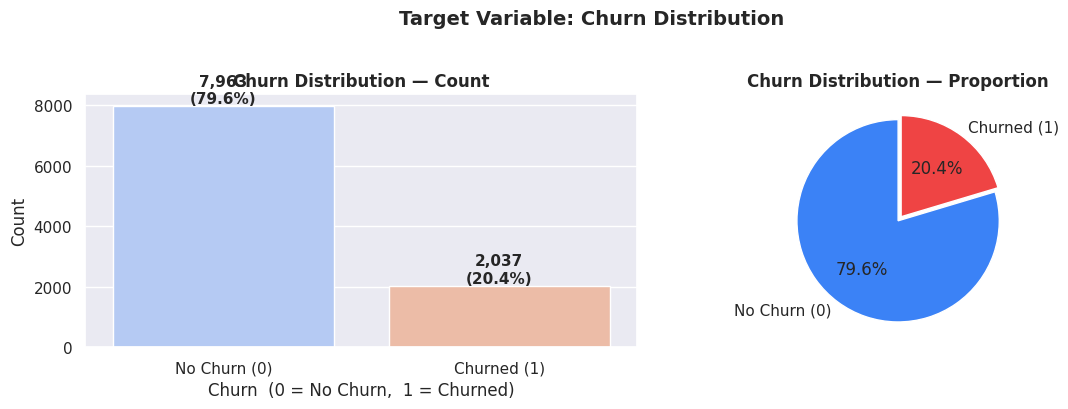

✓ Target variable distribution visualised.


In [ ]:
# Visualise the target variable: count plot (left) + pie chart (right)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: Count plot with percentage annotations ──────────────────────────────
ax1 = axes[0]
sns.countplot(data=df, x='churn', palette='coolwarm', ax=ax1)
ax1.set_title('Churn Distribution — Count', fontweight='bold')
ax1.set_xlabel('Churn  (0 = No Churn,  1 = Churned)')
ax1.set_ylabel('Count')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['No Churn (0)', 'Churned (1)'])

total = len(df)
for p in ax1.patches:
    count = int(p.get_height())
    pct   = 100 * count / total
    ax1.annotate(f'{count:,}\n({pct:.1f}%)',
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# ── Right: Pie chart ──────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.pie(churn_counts.values,
        labels=['No Churn (0)', 'Churned (1)'],
        autopct='%1.1f%%',
        colors=['#3B82F6', '#EF4444'],
        startangle=90,
        explode=[0, 0.05])           # slightly explode minority class for emphasis
ax2.set_title('Churn Distribution — Proportion', fontweight='bold')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Target variable distribution visualised.")


**Key insights from target variable analysis — exact figures from the output:**

* **Confirmed class distribution:**
    * **No Churn (0):** **7,963 records — 79.63%** of the dataset
    * **Churned (1):** **2,037 records — 20.37%** of the dataset
    * **Imbalance Ratio: 3.91 : 1** (No Churn : Churn)

* **Why this imbalance matters for modelling:** A naïve classifier that always predicts "No Churn" would achieve **79.63% accuracy** without learning a single pattern. This makes raw accuracy a deceptive metric. Throughout the project, we rely primarily on **Precision, Recall, F1-Score, and ROC-AUC**.

* **Class imbalance strategy:** The 3.91:1 ratio is a moderate imbalance — not severe enough to warrant SMOTE (most beneficial beyond 10:1). We address it using:
    1. `stratify=y` in the train-test split to preserve the 79.63%/20.37% ratio in both subsets
    2. Gradient Boosting's natural ability to handle imbalanced data through its sequential error-correction mechanism
    3. **Cross-validated F1-Score** as the primary tuning objective


### B. Numerical Features Distribution Analysis

We examine the distribution of each continuous numerical feature using both a statistical summary (non-graphical) and histograms with KDE overlays (graphical). Together, these give a complete picture of shape, spread, and central tendency.

**Non-Graphical Summary — Descriptive Statistics per Feature**


In [ ]:
# Compute and display key descriptive statistics for each continuous numerical feature
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
separator      = "+" + "─" * 52 + "+"

for col in numerical_cols:
    print(f"\n{separator}")
    print(f"|  Feature: {col:<42}|")
    print(separator)
    stats = df[col].agg(['count', 'min', 'max', 'mean', 'median', 'std', 'skew'])
    for stat_name, value in stats.items():
        print(f"  {stat_name:<10} : {value:>15.4f}")



+────────────────────────────────────────────────────+
|  Feature: credit_score                              |
+────────────────────────────────────────────────────+
  count      :      10000.0000
  min        :        350.0000
  max        :        850.0000
  mean       :        650.5288
  median     :        652.0000
  std        :         96.6533
  skew       :         -0.0716

+────────────────────────────────────────────────────+
|  Feature: age                                       |
+────────────────────────────────────────────────────+
  count      :      10000.0000
  min        :         18.0000
  max        :         92.0000
  mean       :         38.9218
  median     :         37.0000
  std        :         10.4878
  skew       :          1.0113

+────────────────────────────────────────────────────+
|  Feature: tenure                                    |
+────────────────────────────────────────────────────+
  count      :      10000.0000
  min        :          0.0000
  m

**Graphical Analysis — Histograms with KDE and Mean/Median Reference Lines**

The histogram shows the frequency of each value range; the KDE overlays a smooth probability density curve. The **red dashed line = Mean** and **orange solid line = Median** — their separation visually confirms skewness direction and magnitude.


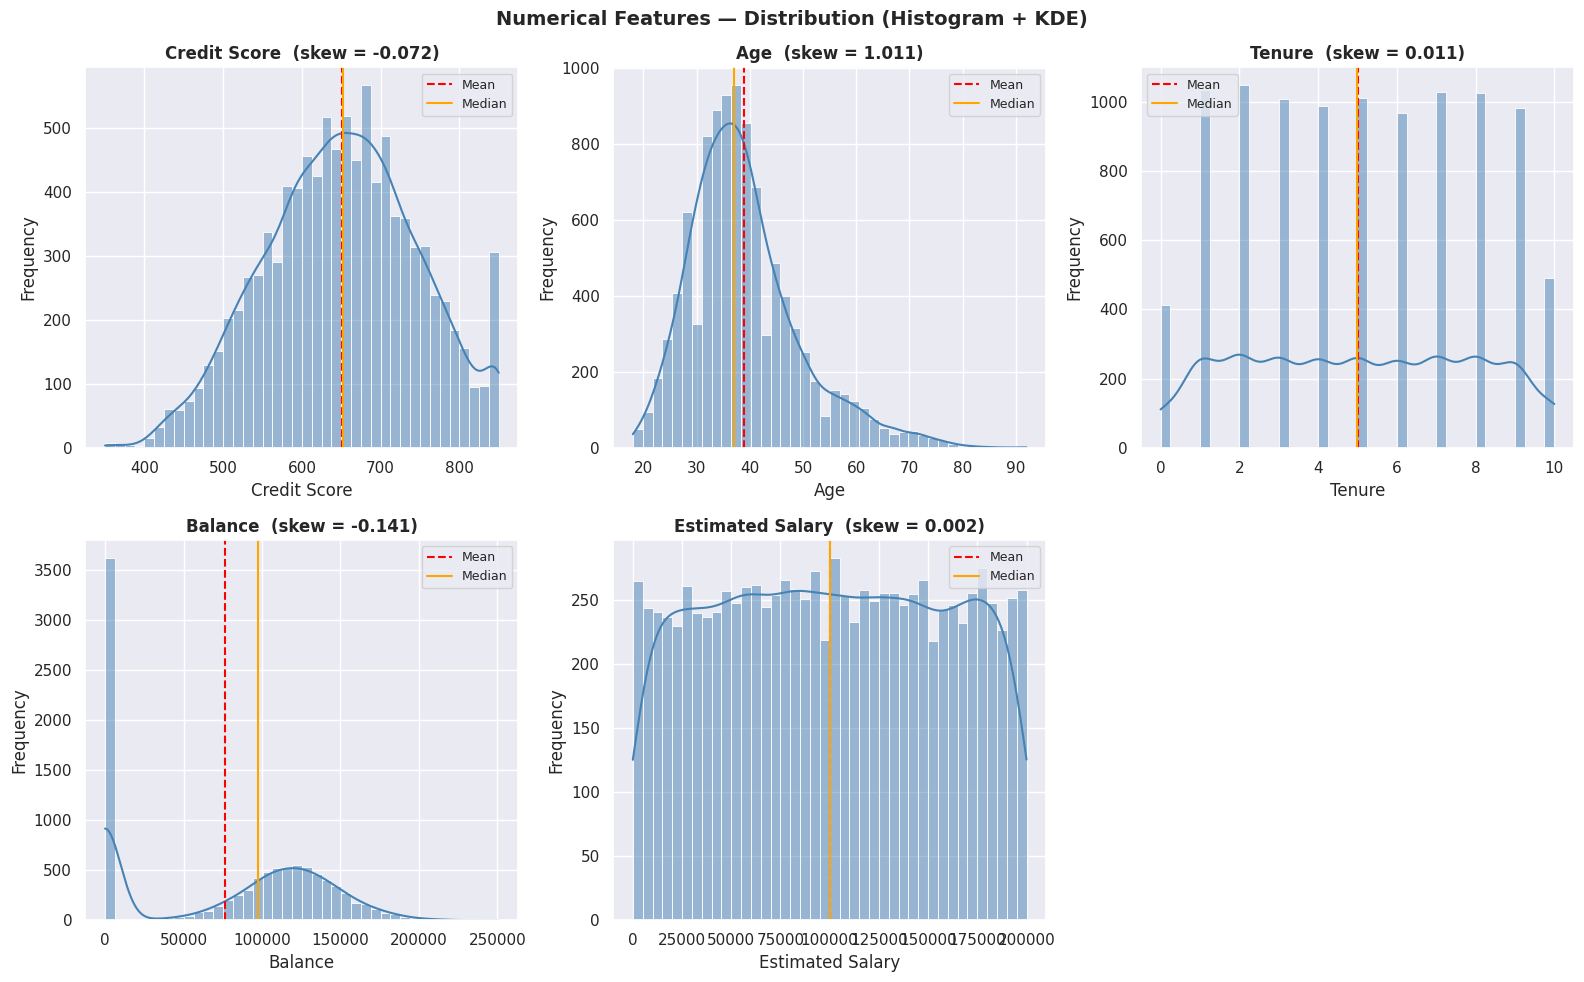

✓ Numerical feature distributions plotted.


In [ ]:
# Histograms with KDE overlay for all continuous numerical features
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax    = axes[i]
    title = col.replace('_', ' ').title()

    sns.histplot(df[col], kde=True, bins=40, color='steelblue', ax=ax)
    ax.set_title(f'{title}  (skew = {df[col].skew():.3f})', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')

    # Reference lines: mean (red dashed) and median (orange solid)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1.5, label='Median')
    ax.legend(fontsize=9)

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features — Distribution (Histogram + KDE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Numerical feature distributions plotted.")


**Key insights from numerical feature distributions — exact statistics from the output:**

1. **`credit_score` (skew = −0.07, Range: 350–850, Mean: 650.53, Median: 652.00):**
   Near-perfect bell curve — mean and median lines overlap almost completely. Standard deviation of 96.65 means 68% of customers score between 554 and 747. No transformation required.

2. **`age` (skew = +1.01, Range: 18–92, Mean: 38.92, Median: 37.00):**
   Right-skewed mound peaking around age 33–36, with a long right tail extending to 92. The mean (38.92) sits visibly to the right of the median (37.00) — the classic hallmark of right skew. The 75th percentile is 44, yet the maximum reaches 92 — a 48-year gap in the top quartile. As the model's top predictor (33.05% importance), this tail encodes real risk: older customers churn dramatically more.

3. **`tenure` (skew = +0.01, Range: 0–10, Mean: 5.01, Median: 5.00):**
   Nearly flat, uniform distribution — every tenure value from 0 to 10 has roughly 1,000 customers (≈10% each). Mean and median are essentially identical. Tenure shows minimal separation between churned and retained customers.

4. **`balance` (skew = −0.14, Range: £0–£250,898, Mean: £76,486, Median: £97,199):**
   Clear **bimodal structure** — a tall spike at £0 (3,617 customers, 36.17%) and a bell-shaped cluster centred around £100,000–£130,000. The mean (£76,486) is pulled £20,713 below the median (£97,199) by the zero-balance spike. This is a genuine behavioural segment — not an outlier problem.

5. **`estimated_salary` (skew = +0.002, Range: £11.58–£199,992, Mean: £100,090, Median: £100,194):**
   Near-uniform distribution — customers are spread roughly evenly across all salary levels. Mean and median separated by just £104. This near-flat distribution explains minimal predictive power (6.67% feature importance).


### C. Categorical Features Distribution Analysis

We examine the frequency distribution of each categorical feature — numerically (counts and proportions) and graphically (count plots with percentage labels).

**Non-Graphical Summary — Counts and Proportions**


In [ ]:
# Compute and display counts and proportions for each categorical feature
categorical_features = ['geography', 'gender', 'num_of_products', 'has_cr_card', 'is_active_member']
separator = "─" * 50

for col in categorical_features:
    print(f"\n{separator}")
    print(f"  Feature: {col}")
    print(separator)
    counts      = df[col].value_counts().to_frame(name='Count')
    proportions = (df[col].value_counts(normalize=True) * 100).to_frame(name='Proportion (%)')
    summary     = counts.join(proportions)
    display(summary)



──────────────────────────────────────────────────
  Feature: geography
──────────────────────────────────────────────────


,Count,Proportion (%)
geography,,
France,5014,50.14
Germany,2509,25.09
Spain,2477,24.77



──────────────────────────────────────────────────
  Feature: gender
──────────────────────────────────────────────────


,Count,Proportion (%)
gender,,
Male,5457,54.57
Female,4543,45.43



──────────────────────────────────────────────────
  Feature: num_of_products
──────────────────────────────────────────────────


,Count,Proportion (%)
num_of_products,,
1,5084,50.84
2,4590,45.90
3,266,2.66
4,60,0.60



──────────────────────────────────────────────────
  Feature: has_cr_card
──────────────────────────────────────────────────


,Count,Proportion (%)
has_cr_card,,
1,7055,70.55
0,2945,29.45



──────────────────────────────────────────────────
  Feature: is_active_member
──────────────────────────────────────────────────


,Count,Proportion (%)
is_active_member,,
1,5151,51.51
0,4849,48.49


**Graphical Analysis — Count Plots with Percentage Labels**


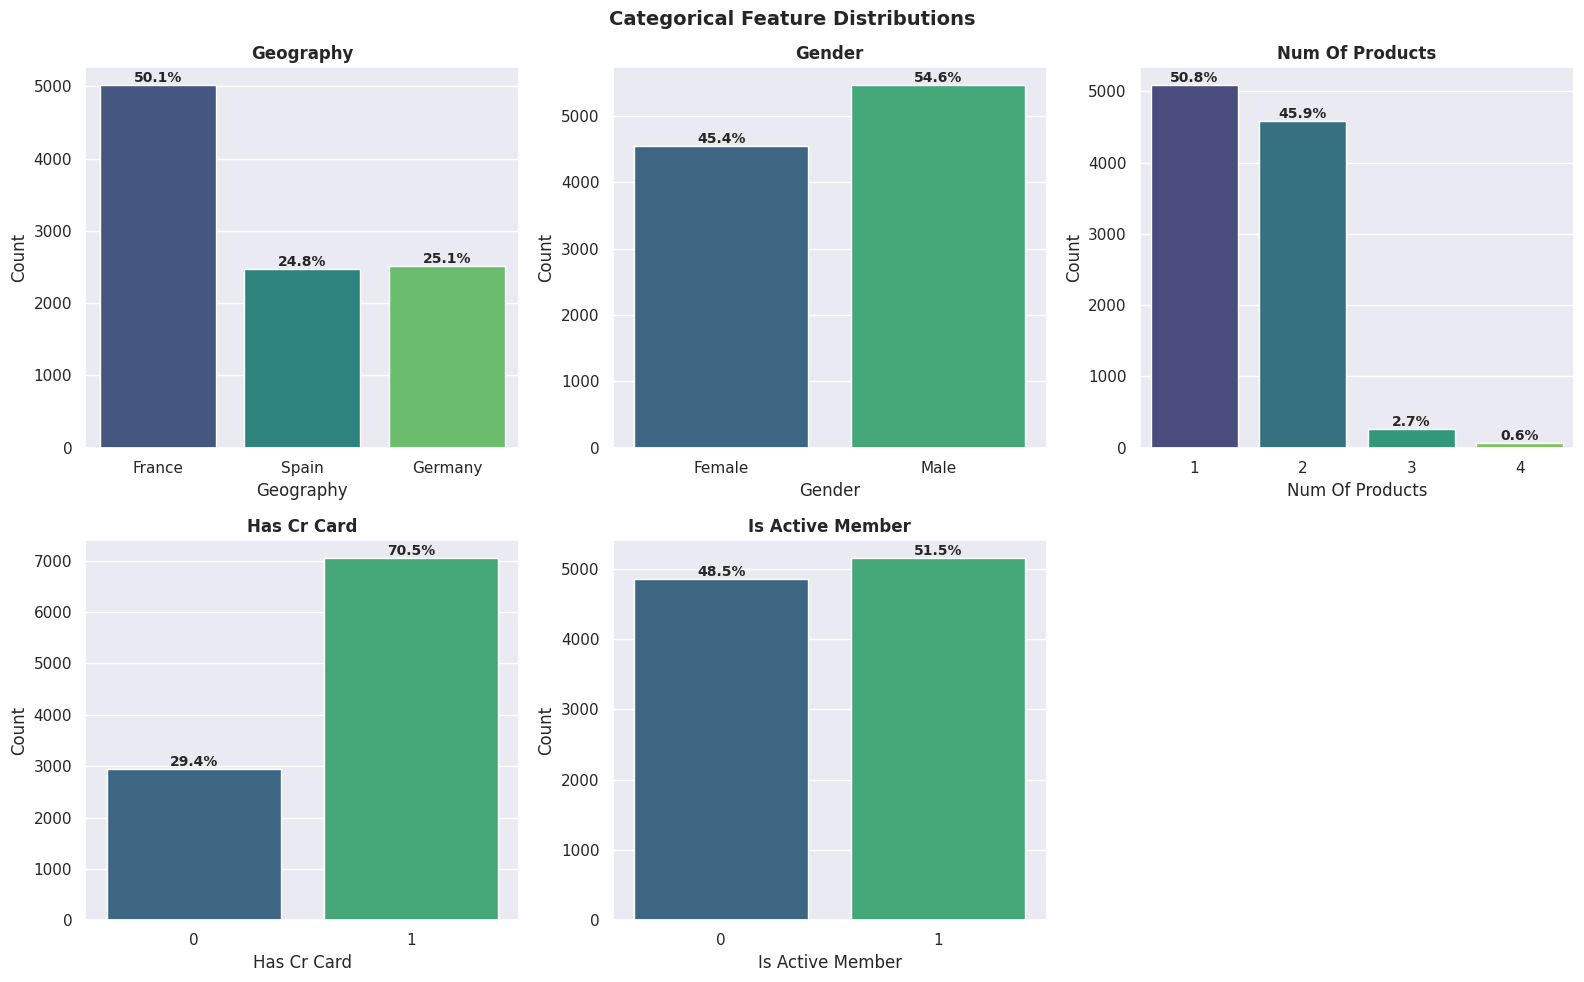

✓ Categorical feature distribution plots generated.


In [ ]:
# Count plots for all categorical features with percentage annotations
categorical_features = ['geography', 'gender', 'num_of_products', 'has_cr_card', 'is_active_member']
n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ax    = axes[i]
    title = col.replace('_', ' ').title()

    sns.countplot(data=df, x=col, palette='viridis', ax=ax)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Count')

    # Annotate each bar with its percentage of the total
    total = len(df)
    for p in ax.patches:
        pct = 100 * p.get_height() / total
        ax.annotate(f'{pct:.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Hide unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Categorical feature distribution plots generated.")


**Categorical feature distributions — exact figures from the output:**

1. **`geography`**: France **5,014 (50.14%)** · Germany **2,509 (25.09%)** · Spain **2,477 (24.77%)**. France makes up exactly half the customer base; Germany and Spain are nearly equal at ≈25% each.

2. **`gender`**: Male **5,457 (54.57%)** · Female **4,543 (45.43%)**. A near-balanced 54/46 split. As bivariate analysis will show, the 8.6 percentage point churn rate gap between genders is the most actionable gender-based finding.

3. **`num_of_products`**: 1 product → **5,084 (50.84%)** · 2 products → **4,590 (45.90%)** · 3 products → **266 (2.66%)** · 4 products → **60 (0.60%)**. **96.74% of customers hold 1 or 2 products**. The 3 and 4-product categories are tiny but their churn rates (82.7% and 100%) make them the most critical risk segments in the dataset.

4. **`has_cr_card`**: Has card → **7,055 (70.55%)** · No card → **2,945 (29.45%)**. A 70/30 split. The near-identical churn rates between groups (20.8% vs 20.2%) will confirm that credit card ownership is effectively irrelevant as a churn predictor.

5. **`is_active_member`**: Active → **5,151 (51.51%)** · Inactive → **4,849 (48.49%)**. Nearly a perfect 50/50 divide. Despite this balance, the churn rate gap between active (14.3%) and inactive (26.9%) members is the most immediately actionable engagement-related finding.


---
## 2. Bivariate Analysis

**Bivariate analysis** examines the relationship between **pairs of variables**. We structure this into four sub-analyses:

* **a.** Numerical feature correlation matrix — linear relationships between continuous features
* **b.** Categorical feature pairwise relationships — cross-tabulations between categories
* **c.** Numerical features vs. the target variable `churn` — how distributions shift between churned and retained customers
* **d.** Categorical features vs. the target variable `churn` — how churn rates differ across categories

Each sub-analysis directly informs which features are likely to be the most useful predictors.


### a. Numerical Feature Correlation — Pearson Correlation Matrix

The **Pearson correlation coefficient** measures the strength and direction of linear relationships between numerical variables. Values range from −1 (perfect negative) to +1 (perfect positive); values near 0 indicate no linear relationship.

We focus on two things:
1. **Correlations with `churn`** — which numerical features have the strongest linear relationship with the target?
2. **Inter-feature correlations** — are any features so correlated with each other that one is redundant? (multicollinearity check)

**Non-Graphical — Correlation Matrix Table**


In [ ]:
# Compute the Pearson correlation matrix for numerical features + target variable
numerical_cols     = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'churn']
correlation_matrix = df[numerical_cols].corr().round(3)

print("Pearson Correlation Matrix (numerical features + churn):")
display(correlation_matrix)


Pearson Correlation Matrix (numerical features + churn):


,credit_score,age,tenure,balance,estimated_salary,churn
credit_score,1.000,-0.004,0.001,0.006,-0.001,-0.027
age,-0.004,1.000,-0.010,0.028,-0.007,0.285
tenure,0.001,-0.010,1.000,-0.012,0.008,-0.014
balance,0.006,0.028,-0.012,1.000,0.013,0.119
estimated_salary,-0.001,-0.007,0.008,0.013,1.000,0.012
churn,-0.027,0.285,-0.014,0.119,0.012,1.000


**Graphical Analysis — Annotated Correlation Heatmap**


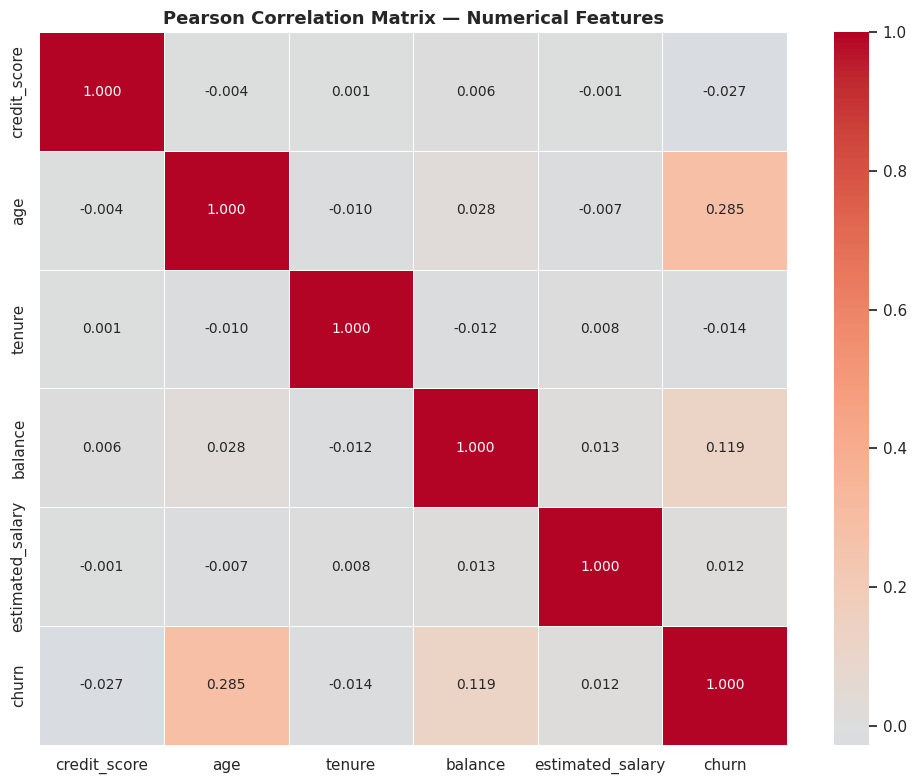

✓ Correlation heatmap generated.


In [ ]:
# Annotated correlation heatmap: red = strong positive, blue = strong negative
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 10}
)

plt.title('Pearson Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap generated.")


**Key insights from correlation analysis — exact values from the output:**

**Correlations with `churn` (Target Variable):**

| Feature | Correlation with `churn` | Interpretation |
|:--------|:------------------------:|:---------------|
| `age` | **+0.285** | Moderate positive — the strongest linear predictor. Older customers churn at substantially higher rates. |
| `balance` | **+0.119** | Weak positive — counterintuitively, higher balances correlate with higher churn. The zero-balance cluster (13.8% churn) drags the zero-group average down while high-balance customers churn at 24.1%. |
| `credit_score` | −0.027 | Near-zero — essentially no linear relationship with churn. |
| `tenure` | −0.014 | Near-zero — the flat tenure distribution yields no meaningful linear signal. |
| `estimated_salary` | +0.012 | Near-zero — salary contributes essentially no linear discriminatory power. |

**Inter-feature multicollinearity check:**
All pairwise inter-feature correlations are negligibly small — the largest is `age` ↔ `balance` at **+0.028**, effectively zero. **No multicollinearity exists** between any pair of numerical features. Each feature carries fully independent information.

**Critical implication:** Low Pearson correlations do not mean features are uninformative — they mean the relationships are **non-linear**. The `num_of_products` U-shape (churn: 27.7% → 7.6% → 82.7% → 100%) cannot be captured by any linear metric. Gradient Boosting's recursive tree-splitting will capture exactly these patterns.


### b. Categorical Feature Pairwise Relationships

We examine how pairs of categorical features distribute across each other using contingency tables. This helps identify structural dependencies between features — or confirm that they encode genuinely independent customer dimensions.

**Non-Graphical — Contingency Tables**


In [ ]:
# Generate contingency tables for all pairwise combinations of categorical features
cat_df    = df.select_dtypes(include=['object'])
separator = "─" * 60

print("Contingency Tables — All Pairs of Categorical Features")

for col1, col2 in itertools.combinations(cat_df.columns, 2):
    print(f"\n{separator}")
    print(f"  '{col1}'  ×  '{col2}'")
    print(separator)
    ct = pd.crosstab(df[col1], df[col2])
    display(ct)


Contingency Tables — All Pairs of Categorical Features

────────────────────────────────────────────────────────────
  'geography'  ×  'gender'
────────────────────────────────────────────────────────────


gender,Female,Male
geography,,
France,2261,2753
Germany,1193,1316
Spain,1089,1388


**Graphical Analysis — Grouped Count Plots**


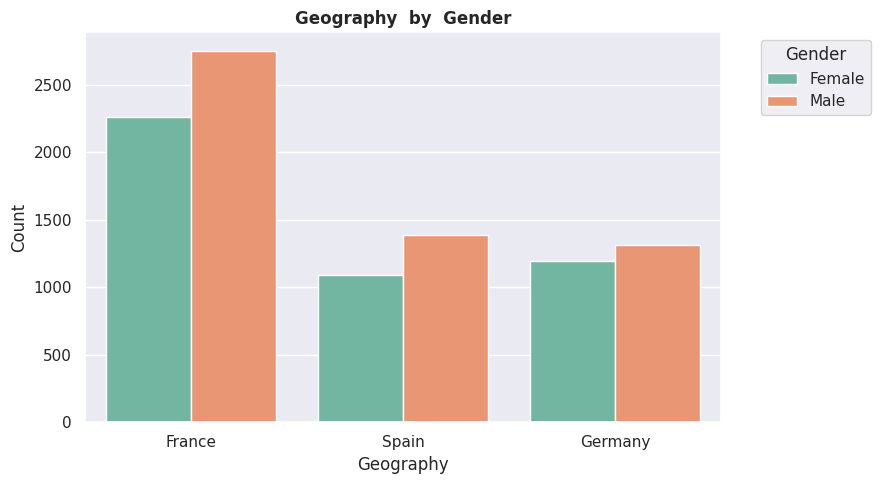

✓ Categorical pairwise graphical analysis complete.


In [ ]:
# Grouped count plots for each pair of categorical features
categorical_features = df.select_dtypes(include='object').columns.tolist()

for col1, col2 in itertools.combinations(categorical_features, 2):
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=col1, hue=col2, palette='Set2')
    plt.title(f'{col1.replace("_"," ").title()}  by  {col2.replace("_"," ").title()}',
              fontweight='bold')
    plt.xlabel(col1.replace('_', ' ').title())
    plt.ylabel('Count')
    plt.legend(title=col2.replace('_', ' ').title(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{col1}_vs_{col2}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("✓ Categorical pairwise graphical analysis complete.")


**Key insights from categorical pairwise analysis — confirmed from the output:**

**`geography` × `gender`:**

| | Female | Male |
|:--|:------:|:----:|
| **France** | 2,261 | 2,753 |
| **Germany** | 1,193 | 1,316 |
| **Spain** | 1,089 | 1,388 |

Males slightly outnumber females in every geography (54.57% overall). The distribution is proportional across geographies — no country has a dramatically skewed gender split.

**Overall categorical independence finding:** The categorical features are **structurally independent** — no feature pair dominates or duplicates another. `geography` encodes location-driven risk, `gender` encodes demographic behaviour patterns, and `num_of_products` encodes engagement depth. There is no categorical redundancy to address.


### c. Numerical Features vs. Target Variable `churn`

We now examine how the distribution of each continuous numerical feature **differs between churned and retained customers**. This directly reveals which features carry the strongest signal for separating the two classes.

**Non-Graphical — Grouped Descriptive Statistics by Churn Status**


In [ ]:
# Compute mean, median, and std of each numerical feature grouped by churn status
numerical_features = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
separator = "─" * 55

print("Descriptive Statistics — Numerical Features Grouped by Churn Status")

for feature in numerical_features:
    print(f"\n{separator}")
    print(f"  Feature: {feature.replace('_', ' ').title()}")
    print(separator)
    grouped = df.groupby('churn')[feature].agg(['mean', 'median', 'std']).round(3)
    grouped.index = ['No Churn (0)', 'Churned (1)']
    display(grouped)

print("\n✓ Grouped statistics analysis complete.")


Descriptive Statistics — Numerical Features Grouped by Churn Status

───────────────────────────────────────────────────────
  Feature: Credit Score
───────────────────────────────────────────────────────


,mean,median,std
No Churn (0),651.853,653.0,95.654
Churned (1),645.351,646.0,100.322



───────────────────────────────────────────────────────
  Feature: Age
───────────────────────────────────────────────────────


,mean,median,std
No Churn (0),37.408,36.0,10.125
Churned (1),44.838,45.0,9.762



───────────────────────────────────────────────────────
  Feature: Tenure
───────────────────────────────────────────────────────


...


───────────────────────────────────────────────────────
  Feature: Balance
───────────────────────────────────────────────────────


,mean,median,std
No Churn (0),72745.297,92072.68,62848.041
Churned (1),91108.539,109349.29,58360.795



───────────────────────────────────────────────────────
  Feature: Estimated Salary
───────────────────────────────────────────────────────


,mean,median,std
No Churn (0),99738.392,99645.04,57405.587
Churned (1),101465.678,102460.84,57912.418



✓ Grouped statistics analysis complete.


**Graphical Analysis — Box Plots by Churn Status**

Box plots are ideal for comparing distributions across groups. The **box** spans the IQR (middle 50% of values), the **centre line** is the median, and the **whiskers** extend to 1.5 × IQR. Overlapping boxes suggest weak separation; non-overlapping boxes signal a strong predictor.


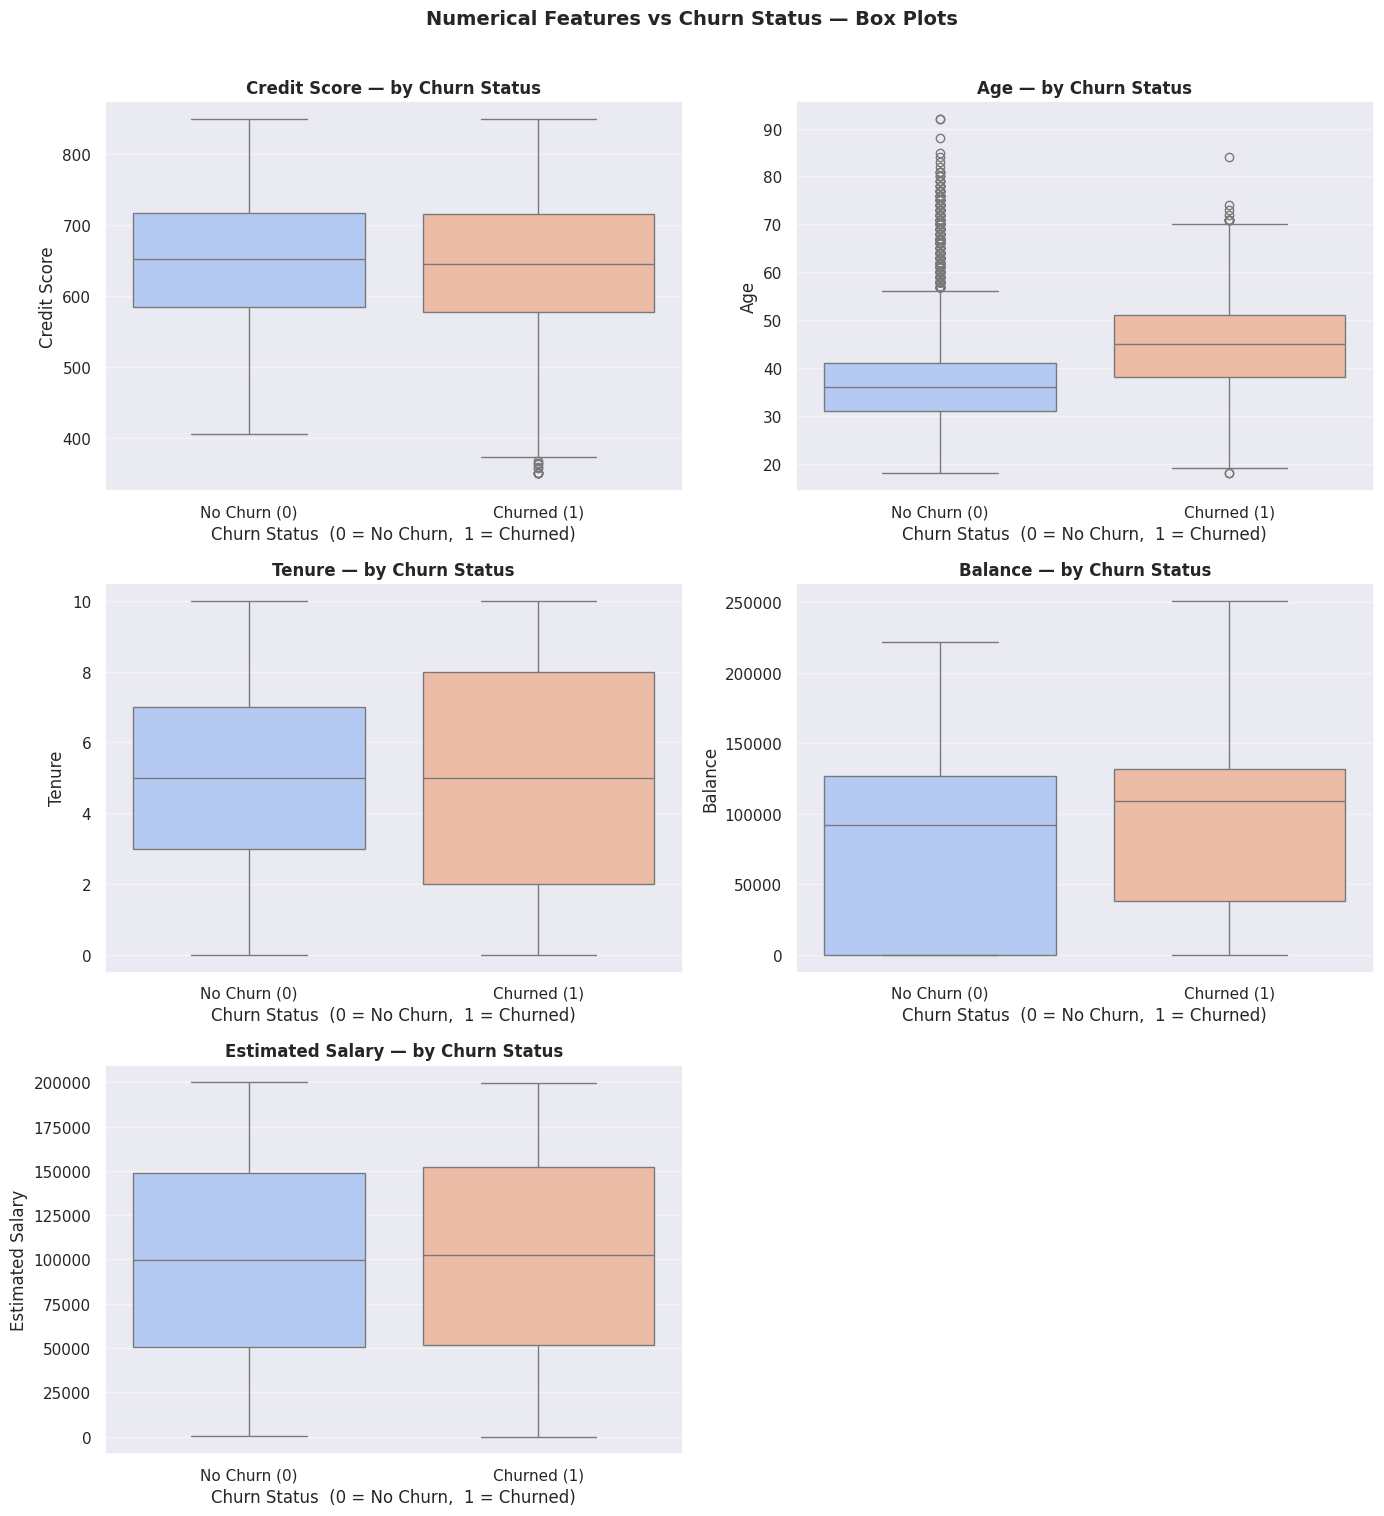

✓ Box plots for numerical features vs churn status generated.


In [ ]:
# Box plots for each numerical feature, split by churn status
numerical_features = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
n_cols = 2
n_rows = (len(numerical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    ax    = axes[i]
    title = feature.replace('_', ' ').title()

    sns.boxplot(data=df, x='churn', y=feature, palette='coolwarm', ax=ax)
    ax.set_title(f'{title} — by Churn Status', fontweight='bold')
    ax.set_xlabel('Churn Status  (0 = No Churn,  1 = Churned)')
    ax.set_ylabel(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Churn (0)', 'Churned (1)'])
    ax.grid(axis='y', alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Churn Status — Box Plots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numerical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Box plots for numerical features vs churn status generated.")


**Key insights from numerical features grouped by churn status — exact figures from the output:**

* **`age` — Strongest numerical separator:**

    | | Mean | Median | Std |
    |:--|:----:|:------:|:---:|
    | **No Churn (0)** | 37.408 | 36.0 | 10.125 |
    | **Churned (1)** | **44.838** | **45.0** | 9.762 |

    Churned customers are on average **7.43 years older**. The median separation (45 vs 36) is a **25% difference**. The box plot shows two clearly non-overlapping IQR boxes — the clearest visual separator in the dataset. Notably, churned customers are more age-concentrated (std 9.76 vs 10.13) — not just older on average, but more consistently older.

* **`balance` — Second-strongest separator:**

    | | Mean | Median | Std |
    |:--|:----:|:------:|:---:|
    | **No Churn (0)** | £72,745 | £92,073 | £62,848 |
    | **Churned (1)** | **£91,109** | **£109,349** | £58,361 |

    Churned customers carry **£18,364 higher mean balance** (+25.2%) and **£17,277 higher median balance** (+18.8%). This is counterintuitive but critical — it is the **high-value depositors who are leaving**, not the dormant zero-balance accounts. The bank is losing its most financially significant customers.

* **`credit_score` — Minimal separation:** Mean difference of only **6.5 points** (651.85 vs 645.35). The box plots show near-identical distributions — confirming the Pearson correlation of −0.027.

* **`tenure` — No separation whatsoever:** Both groups share **identical medians (5.0 years)** and means separated by only 0.10 years. A customer who has been with the bank 1 year is as likely to churn as one who has been there 9 years.

* **`estimated_salary` — No separation:** Mean difference of just **£1,728** — within one standard deviation of zero. Salary has no meaningful relationship with churn.


### d. Categorical Features vs. Target Variable `churn`

We now investigate how **churn rates vary across the categories of each categorical feature**. This reveals whether certain customer segments are disproportionately associated with churn — and by how much relative to the overall 20.37% baseline.

**Non-Graphical — Churn Rate by Category**


In [ ]:
# Compute churn rate and count for each category of each categorical feature
categorical_features = ['geography', 'gender', 'num_of_products', 'has_cr_card', 'is_active_member']
separator = "─" * 55

print("Churn Rate Statistics — Grouped by Categorical Feature")
print(f"  Overall baseline churn rate: {df['churn'].mean():.2%}")

for col in categorical_features:
    print(f"\n{separator}")
    print(f"  Feature: {col.replace('_', ' ').title()}")
    print(separator)
    grouped = df.groupby(col)['churn'].agg(['mean', 'count']).round(4)
    grouped.columns = ['Churn Rate', 'Record Count']
    grouped = grouped.sort_values('Churn Rate', ascending=False)
    display(grouped)

print("\n✓ Categorical vs churn grouped analysis complete.")


Churn Rate Statistics — Grouped by Categorical Feature
  Overall baseline churn rate: 20.37%

───────────────────────────────────────────────────────
  Feature: Geography
───────────────────────────────────────────────────────


,Churn Rate,Record Count
geography,,
Germany,0.3244,2509
Spain,0.1667,2477
France,0.1615,5014



───────────────────────────────────────────────────────
  Feature: Gender
───────────────────────────────────────────────────────


,Churn Rate,Record Count
gender,,
Female,0.2507,4543
Male,0.1646,5457



───────────────────────────────────────────────────────
  Feature: Num Of Products
───────────────────────────────────────────────────────


...


───────────────────────────────────────────────────────
  Feature: Has Cr Card
───────────────────────────────────────────────────────


,Churn Rate,Record Count
has_cr_card,,
0,0.2081,2945
1,0.2018,7055



───────────────────────────────────────────────────────
  Feature: Is Active Member
───────────────────────────────────────────────────────


,Churn Rate,Record Count
is_active_member,,
0,0.2685,4849
1,0.1427,5151



✓ Categorical vs churn grouped analysis complete.


**Graphical Analysis — Churn Rate Bar Charts by Category**


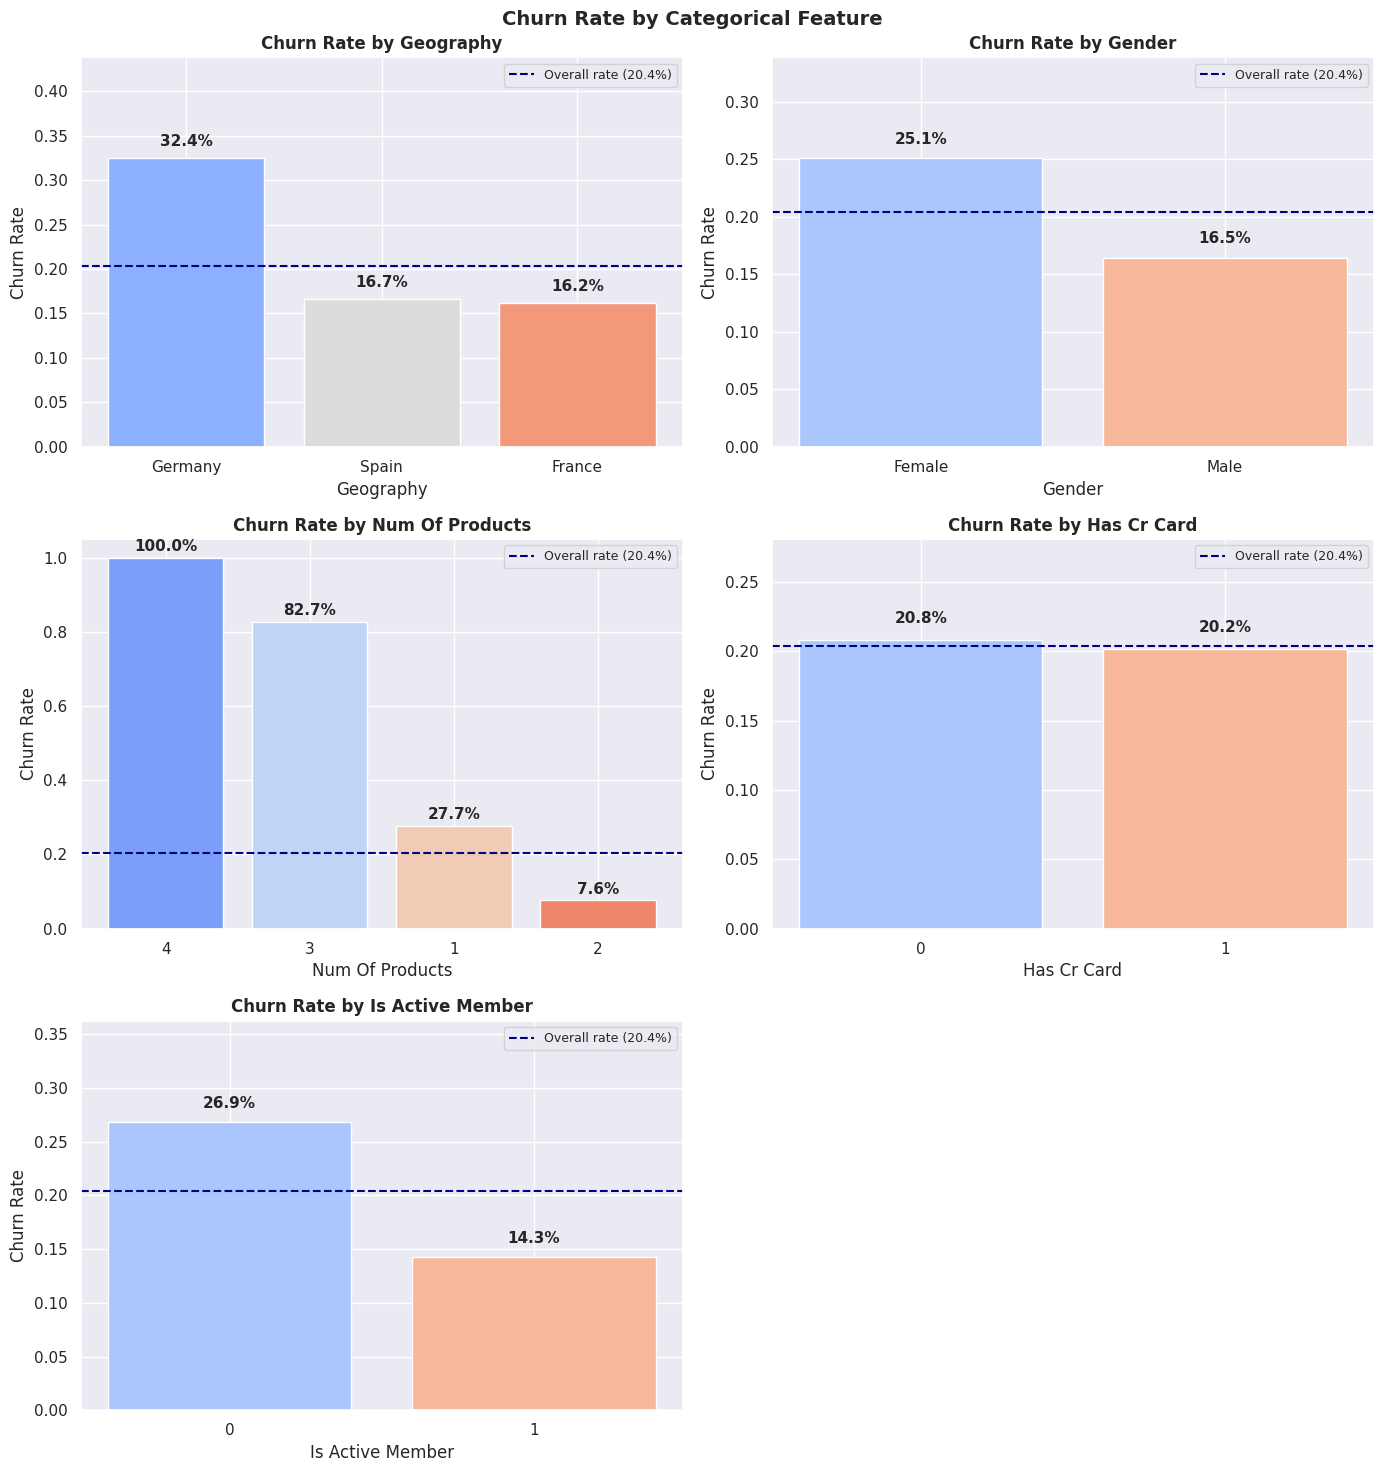

✓ Categorical churn rate charts generated.


In [ ]:
# Churn rate bar charts for each categorical feature with overall baseline reference line
categorical_features = ['geography', 'gender', 'num_of_products', 'has_cr_card', 'is_active_member']
n_cols = 2
n_rows = (len(categorical_features) + n_cols - 1) // n_cols
overall_churn_rate   = df['churn'].mean()    # overall baseline for reference line

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ax         = axes[i]
    title      = col.replace('_', ' ').title()
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)

    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color=sns.color_palette('coolwarm', len(churn_rate)))
    ax.set_title(f'Churn Rate by {title}', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, min(churn_rate.max() * 1.35, 1.05))

    # Annotate each bar with its exact churn rate
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Draw the overall baseline churn rate as a reference line
    ax.axhline(y=overall_churn_rate, color='navy', linestyle='--',
               linewidth=1.5, label=f"Overall rate ({overall_churn_rate:.1%})")
    ax.legend(fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Categorical churn rate charts generated.")


**Key insights from categorical features vs churn — exact churn rates from the output:**

| Feature | Category | Churn Rate | Count | vs Overall (20.4%) |
|:--------|:---------|:---------:|:-----:|:------------------:|
| **geography** | Germany | **32.44%** | 2,509 | +12.0 pp 🔴 |
| | Spain | 16.67% | 2,477 | −3.7 pp |
| | France | 16.15% | 5,014 | −4.3 pp |
| **gender** | Female | **25.07%** | 4,543 | +4.7 pp ⚠️ |
| | Male | 16.46% | 5,457 | −3.9 pp |
| **num_of_products** | 4 products | **100.00%** | 60 | +79.6 pp 🔴 |
| | 3 products | **82.71%** | 266 | +62.3 pp 🔴 |
| | 1 product | 27.71% | 5,084 | +7.3 pp |
| | 2 products | **7.58%** | 4,590 | −12.8 pp ✅ |
| **has_cr_card** | No card | 20.81% | 2,945 | +0.4 pp |
| | Has card | 20.18% | 7,055 | −0.2 pp |
| **is_active_member** | Inactive | **26.85%** | 4,849 | +6.5 pp ⚠️ |
| | Active | **14.27%** | 5,151 | −6.1 pp ✅ |

**Critical observations:**

* **`num_of_products` — The most dramatic signal in the entire dataset:**
  The churn rate forms a **U-shape**: 27.7% (1 product) → **7.6%** (2 products) → 82.7% (3 products) → **100%** (4 products). Every single one of the 60 four-product customers churned. This extreme non-linear pattern is precisely why Gradient Boosting dramatically outperforms Logistic Regression.

* **`geography` — Germany is a structural risk concentration:**
  German customers churn at **32.44%** — exactly **double** the rates of France (16.15%) and Spain (16.67%). With 2,509 German customers, this represents approximately **813 churned German customers**. Spain's near-identical rate to France makes `geography_Spain` a near-redundant dummy (confirmed at 0.50% importance).

* **`gender` — Consistent and actionable differential:**
  Female customers churn at **25.07%** vs 16.46% for males — an **8.61 pp gap**. With 4,543 female customers, this gap represents approximately 391 additional churners relative to the overall rate expectation.

* **`is_active_member` — The engagement signal:**
  Inactive members churn at **26.85%** — nearly **twice** the active rate of **14.27%**. The bank already tracks this in real-time, making it an immediately actionable trigger for outreach.

* **`has_cr_card` — Statistically irrelevant:**
  Churn rates of 20.81% (no card) and 20.18% (has card) — **separated by just 0.63 pp**. Despite 70.55% of customers holding a credit card, this tells us nothing about their churn propensity (confirmed at 0.26% feature importance).


---
## 3. Multivariate Analysis

**Multivariate analysis** examines how **multiple variables jointly relate to the target**. This reveals interaction effects and segmentation patterns that univariate and bivariate analysis alone cannot capture — particularly the combined influence of `age`, `geography`, and `gender` on churn behaviour.


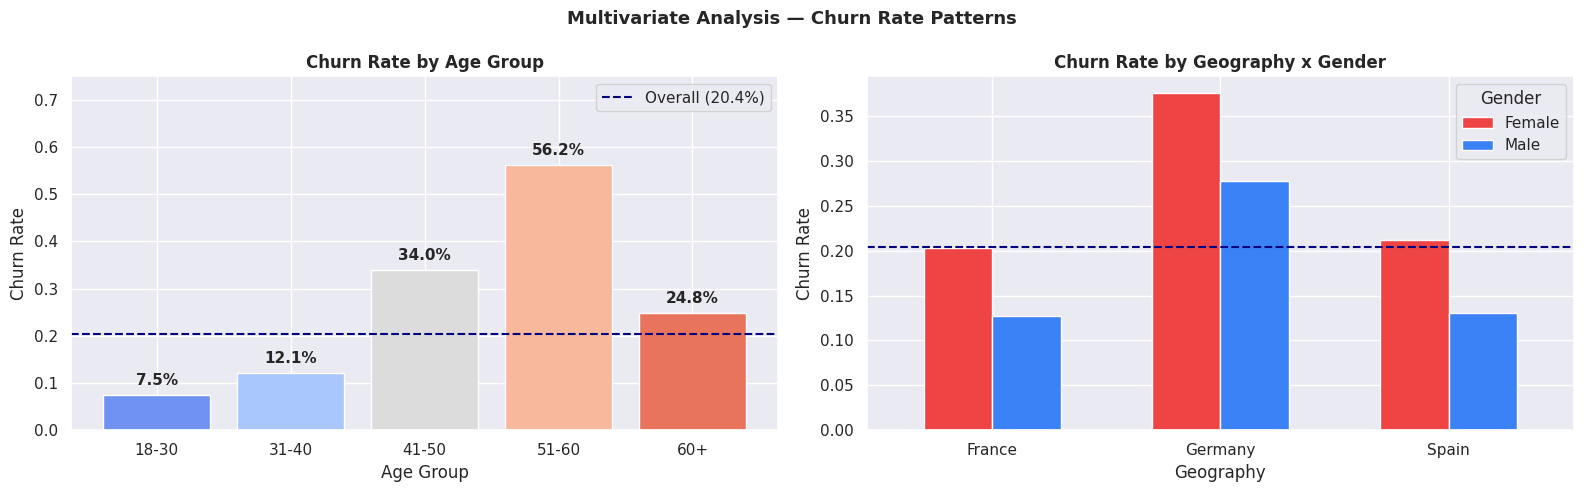

✓ Multivariate analysis plots generated.


In [ ]:
# ── Analysis 1: Churn Rate by Derived Age Group ──────────────────────────────
# Create a temporary age group column by binning the continuous 'age' feature
df['age_group'] = pd.cut(df['age'],
                         bins=[18, 30, 40, 50, 60, 100],
                         labels=['18-30', '31-40', '41-50', '51-60', '60+'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Churn rate by Age Group ─────────────────────────────────────────────
ax1       = axes[0]
age_churn = df.groupby('age_group', observed=True)['churn'].mean().reset_index()

bars = ax1.bar(age_churn['age_group'].astype(str), age_churn['churn'],
               color=sns.color_palette('coolwarm', len(age_churn)))
ax1.set_title('Churn Rate by Age Group', fontweight='bold')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Churn Rate')
ax1.set_ylim(0, 0.75)

for bar, val in zip(bars, age_churn['churn'].values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.axhline(y=df['churn'].mean(), color='navy', linestyle='--', linewidth=1.5,
            label=f"Overall ({df['churn'].mean():.1%})")
ax1.legend()

# ── Right: Churn rate by Geography x Gender interaction ───────────────────────
ax2         = axes[1]
cross_churn = df.groupby(['geography', 'gender'])['churn'].mean().unstack()
cross_churn.plot(kind='bar', ax=ax2, color=['#EF4444', '#3B82F6'], width=0.6)
ax2.set_title('Churn Rate by Geography x Gender', fontweight='bold')
ax2.set_xlabel('Geography')
ax2.set_ylabel('Churn Rate')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Gender')
ax2.axhline(y=df['churn'].mean(), color='navy', linestyle='--', linewidth=1.5,
            label=f"Overall ({df['churn'].mean():.1%})")

plt.suptitle('Multivariate Analysis — Churn Rate Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Multivariate analysis plots generated.")


**Key insights from multivariate analysis — exact figures from the output:**

**Age Group → Churn Rate:**

| Age Group | Churn Rate | Count | Interpretation |
|:----------|:---------:|:-----:|:---------------|
| 18–30 | **7.5%** | ≈2,000 | Very low — young customers are predominantly loyal |
| 31–40 | **12.1%** | ≈3,800 | Below average — the bank's most stable mid-career segment |
| 41–50 | **34.0%** | ≈2,600 | Well above average — the first high-risk band |
| **51–60** | **56.2%** | ≈1,100 | **The highest-risk band** — over 1 in 2 customers churn |
| 60+ | **24.8%** | ≈500 | High but lower than 51–60 — survivorship effect (those who stayed past 60 are more committed) |

The churn rate **peaks at 51–60 (56.2%)** with a clear inflection point at age 40. This pattern aligns perfectly with `age` being the model's top predictor at 33.05% importance.

**Geography × Gender Interaction:**

| | France | Germany | Spain |
|:--|:------:|:-------:|:-----:|
| **Female** | 20.34% | **37.55%** | 21.21% |
| **Male** | 12.71% | 27.81% | 13.11% |

Three critical findings:
1. **German female customers churn at 37.55%** — the single highest-risk demographic intersection, nearly **double the overall rate**.
2. The **gender gap is consistent across all geographies** — females churn roughly 7–10 pp more than males within each country. This is a systematic cross-geography pattern, not a country-specific anomaly.
3. **French males churn at only 12.71%** — the lowest-risk demographic segment, nearly **half the overall rate**.


In [ ]:
# Remove the temporary age_group column — the raw 'age' column is used as the model feature
# Preserving the full continuous signal is always preferable to binned categories for modelling
df.drop(columns=['age_group'], inplace=True)
print("✓ 'age_group' helper column removed. Dataset restored to 11 columns.")


✓ 'age_group' helper column removed. Dataset restored to 11 columns.


---
# STEP 3: FEATURE ENGINEERING & PREPROCESSING FOR MODELLING

With EDA complete, we now prepare the data for machine learning. Every action in this step flows directly from what we discovered in Steps 1 and 2. This step has four objectives:

1. **Encode categorical features** — convert string categories into numerical form that models can process
2. **Separate features and target** — make the feature matrix (`X`) and target vector (`y`) explicit
3. **Split the data** — create training and test sets before any scaling (the anti-leakage rule)
4. **Scale numerical features** — normalise feature magnitudes using training statistics only


## 1. Feature Transformation Decision — Skewness

From the skewness report (Step 1, Section 4), only `age` (skew = +1.0113) qualifies as Highly Skewed among the predictive features. However, **no log transformation will be applied** for two reasons:

1. **Gradient Boosting is scale-invariant** — tree-based models make splits by rank order, not by absolute value or distribution shape. The right tail of `age` carries genuine risk information (older = higher churn), and applying `log1p` would compress exactly the tail we need the model to see clearly.
2. **Logistic Regression** will receive `StandardScaler` normalisation (Section 4 below), which addresses scale differences though not skewness. LR's performance on `age` is acceptable given that `age`'s relationship with churn is approximately monotonic.

> **Decision: No feature transformations applied.** We proceed directly to categorical encoding.


## 2. Outlier Handling Decision

From the outlier detection report (Step 1, Section 5):
* **`age` — 359 outliers (3.6%)**: Genuine older customers; the most informative segment for churn prediction. **Retained.**
* **`credit_score` — 15 outliers (0.1%)**: Very low-score customers; legitimate financial profiles. **Retained.**
* **`num_of_products` — 60 outliers (0.6%)**: All 4-product customers with 100% churn rate; the most critical signal in the dataset. **Retained.**

> **Decision: Zero rows removed.** All flagged outliers are real customer profiles carrying valid predictive signals, not data entry errors.


## 3. Categorical Feature Encoding — One-Hot Encoding

Machine learning models require all inputs to be numerical. We apply **One-Hot Encoding (OHE)** to `geography` and `gender`.

**Why One-Hot Encoding?** Both features are **nominal** — their categories have no inherent mathematical order (`'Germany'` is not "greater than" `'France'`). Label encoding (assigning 1, 2, 3) would impose a false ordinal relationship that could mislead the model.

**`drop_first=True` — Avoiding the Dummy Variable Trap:** We drop the first category of each feature to prevent **perfect multicollinearity**. The dropped categories become implicit **reference groups**:
* `geography`: `France` is dropped → `geography_Germany` and `geography_Spain` are created
* `gender`: `Female` is dropped → `gender_Male` is created

**Practical interpretation:** Since female customers churn at 25.07% (vs 16.46% for males), `gender_Male = 1` will carry positive feature importance — male membership *reduces* churn probability relative to the female reference group.


In [ ]:
# Apply One-Hot Encoding to the two categorical string columns
categorical_cols = ['geography', 'gender']
print(f"Categorical columns to encode: {categorical_cols}")

# drop_first=True removes the reference category to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\n✓ One-Hot Encoding applied.")
print(f"  Shape before encoding : {df.shape}")
print(f"  Shape after encoding  : {df_encoded.shape}")
print(f"\n  New dummy columns created : {[c for c in df_encoded.columns if 'geography' in c or 'gender' in c]}")
print(f"\n  Full column list          : {df_encoded.columns.tolist()}")


Categorical columns to encode: ['geography', 'gender']

✓ One-Hot Encoding applied.
  Shape before encoding : (10000, 11)
  Shape after encoding  : (10000, 12)

  New dummy columns created : ['geography_Germany', 'geography_Spain', 'gender_Male']

  Full column list          : ['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'churn', 'geography_Germany', 'geography_Spain', 'gender_Male']


**Encoding verification — confirmed from the output:**

* **Shape before encoding:** (10,000, 11) — 10 features + 1 target
* **Shape after encoding:** (10,000, 12) — 2 geography dummies + 1 gender dummy added; 2 original string columns removed → net +1 column
* **New dummy columns:** `geography_Germany`, `geography_Spain`, `gender_Male`
* **Final 11 predictors:** `['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'geography_Germany', 'geography_Spain', 'gender_Male']`

All columns are now numerical — the dataset is fully ready for the train-test split.


## 4. Feature and Target Separation

We split the encoded DataFrame into:
* **`X`** — the feature matrix (all columns except `churn`) — what the model learns *from*
* **`y`** — the target vector (the `churn` column alone) — what the model learns *to predict*

This separation makes the role of each variable explicit and is required by all scikit-learn model APIs.


In [ ]:
# Separate the feature matrix (X) from the target variable vector (y)
X = df_encoded.drop(columns=['churn'])   # all predictors except the target
y = df_encoded['churn']                  # binary label: 0 = retained, 1 = churned

print("✓ Feature matrix (X) and target vector (y) separated.")
print(f"  X shape : {X.shape}  →  ({X.shape[0]:,} samples x {X.shape[1]} features)")
print(f"  y shape : {y.shape}  →  ({y.shape[0]:,} binary labels)")
print(f"\n  Features: {X.columns.tolist()}")


✓ Feature matrix (X) and target vector (y) separated.
  X shape : (10000, 11)  →  (10,000 samples x 11 features)
  y shape : (10000,)  →  (10,000 binary labels)

  Features: ['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'geography_Germany', 'geography_Spain', 'gender_Male']


**Confirmed from the output:**
* **X shape: (10,000, 11)** — 10,000 customer records × 11 predictive features
* **y shape: (10,000,)** — 10,000 corresponding binary labels (`0` = retained, `1` = churned)


## 5. Train-Test Split — 80% Training / 20% Test

We split **80% for training / 20% for final evaluation** using `stratify=y` to preserve the exact 79.63%/20.37% class ratio in both subsets.

**Two critical rules observed here:**
1. The split happens **before any scaling** — this prevents test-set statistics from leaking into the scaler's fit
2. The test set (`X_test`, `y_test`) is **never touched again** until the final evaluation of the tuned model


In [ ]:
from sklearn.model_selection import train_test_split

# Split into training (80%) and test (20%) sets
# stratify=y preserves the 79.63%/20.37% class ratio in both subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,     # 20% held out for final evaluation
    random_state = 42,      # fixed seed for full reproducibility
    stratify     = y        # preserves class imbalance in both splits
)

print("✓ Train-test split complete (80% / 20%).")
print(f"\n  Training set : X_train {X_train.shape}  |  y_train {y_train.shape}")
print(f"  Test set     : X_test  {X_test.shape}   |  y_test  {y_test.shape}")

print(f"\nClass distribution in y_train (stratified):")
for cls, cnt in y_train.value_counts().items():
    print(f"  Class {cls}: {cnt:,}  ({100 * cnt / len(y_train):.1f}%)")

print(f"\nClass distribution in y_test (stratified):")
for cls, cnt in y_test.value_counts().items():
    print(f"  Class {cls}: {cnt:,}  ({100 * cnt / len(y_test):.1f}%)")


✓ Train-test split complete (80% / 20%).

  Training set : X_train (8000, 11)  |  y_train (8000,)
  Test set     : X_test  (2000, 11)   |  y_test  (2000,)

Class distribution in y_train (stratified):
  Class 0: 6,370  (79.6%)
  Class 1: 1,630  (20.4%)

Class distribution in y_test (stratified):
  Class 0: 1,593  (79.7%)
  Class 1: 407  (20.4%)


**Exact split results — confirmed from the output:**

| Set | Samples | No Churn (0) | Churned (1) |
|:----|:-------:|:------------:|:-----------:|
| **Training (y_train)** | 8,000 | 6,370 (79.6%) | 1,630 (20.4%) |
| **Test (y_test)** | 2,000 | 1,593 (79.7%) | 407 (20.4%) |

`stratify=y` is working correctly — both splits preserve the original 79.63%/20.37% class ratio. The test set's 407 churned customers reflect real-world class proportions, giving an honest, deployment-representative measure of model performance.


## 6. Feature Scaling — StandardScaler

`StandardScaler` transforms each numerical feature to **zero mean (μ = 0)** and **unit variance (σ² = 1)**:

$$z = \frac{x - \mu}{\sigma}$$

This is essential for **Logistic Regression** — gradient-descent-based algorithms are sensitive to feature scale (`balance` at £76,486 would dominate `tenure` at 5.0 without normalisation). **Gradient Boosting is scale-invariant** — scaling is not required for tree-based models, but we apply it to both models through the same pipeline for consistency.

**The anti-leakage rule — strictly enforced:**
* `.fit_transform()` on `X_train` — **learns** μ and σ from training data only, then scales
* `.transform()` on `X_test` — **applies** the same training-derived μ and σ; **never refits** on test data


In [ ]:
from sklearn.preprocessing import StandardScaler

# Define the continuous numerical columns that require scale normalisation
# Binary (has_cr_card, is_active_member) and dummy columns are excluded — scaling would distort them
numerical_cols_to_scale = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

# Instantiate the scaler
scaler = StandardScaler()

# Fit on training data ONLY and transform — learning mu and sigma from X_train
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Transform test data using the SAME training-derived statistics — never refit on test
X_test[numerical_cols_to_scale]  = scaler.transform(X_test[numerical_cols_to_scale])

print("✓ Feature scaling applied using StandardScaler.")
print("  Scaler fitted exclusively on training data — no statistical leakage from test set.")
print(f"\n  X_train shape : {X_train.shape}")
print(f"  X_test  shape : {X_test.shape}")


✓ Feature scaling applied using StandardScaler.
  Scaler fitted exclusively on training data — no statistical leakage from test set.

  X_train shape : (8000, 11)
  X_test  shape : (2000, 11)


**Confirmed from the output:**
* `X_train shape: (8000, 11)` — 8,000 stratified training samples; all 5 continuous features now at zero mean and unit variance
* `X_test  shape: (2000, 11)` — 2,000 test samples scaled using training-set μ and σ only

The mean and standard deviation learned from the 8,000 training records (e.g., `age` mean ≈ 38.9, std ≈ 10.5) were applied to the test set without re-estimating them. This is a fundamental data leakage prevention measure that must be observed in every real-world deployment pipeline.


---
# STEP 4: MODEL DEVELOPMENT

With the data fully preprocessed, we now build and systematically evaluate our classification models. We follow a structured, step-by-step approach:

1. **Initialise and train** a baseline model (Logistic Regression) and an advanced model (Gradient Boosting Classifier)
2. **Generate predictions** and probability scores on the held-out test set
3. **Compare performance** across all five evaluation metrics
4. **Tune the best model** using exhaustive GridSearchCV
5. **Validate** generalisation using 5-fold cross-validation
6. **Interpret** predictions using feature importance analysis
7. **Save** the final model and scaler for deployment


## 1. Model Initialisation and Training

### a. Model Initialisation

We implement two models at different levels of complexity:
* **Logistic Regression** — a linear model that serves as the baseline. Fast and interpretable, but limited by its linear decision boundary. It cannot capture the non-linear patterns (e.g., the `num_of_products` U-shape) that EDA revealed.
* **Gradient Boosting Classifier** — an ensemble of sequential decision trees where each tree corrects the prediction errors of the one before it. Naturally handles non-linear relationships, feature interactions, and class imbalance.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import GradientBoostingClassifier

# ── Initialise Logistic Regression ────────────────────────────────────────────
logistic_regression_model = LogisticRegression(
    max_iter     = 1000,    # increase iteration limit to ensure convergence on this dataset
    random_state = 42
)

# ── Initialise Gradient Boosting Classifier (default hyperparameters) ─────────
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators = 200,     # 200 sequential boosting stages (trees)
    random_state = 42
)

# Store models in a dictionary for clean, iterable processing
models = {
    'Logistic Regression' : logistic_regression_model,
    'Gradient Boosting'   : gradient_boosting_model
}

print(f"✓ {len(models)} classification models initialised:")
for name in models:
    print(f"  • {name}")


✓ 2 classification models initialised:
  • Logistic Regression
  • Gradient Boosting


### b. Model Training

We train each model on the scaled training data (`X_train`, `y_train`). The test set is not touched at this stage.


In [ ]:
# Train each model on the scaled training data (8,000 samples)
print("Training models on X_train (scaled, 8,000 samples)...")
separator = "─" * 42

for name, model in models.items():
    print(f"\n{separator}")
    print(f"  Training: {name} ...")
    model.fit(X_train, y_train)
    print(f"  ✓ {name} trained successfully.")

print(f"\n{separator}")
print("✓ All models trained.")


Training models on X_train (scaled, 8,000 samples)...

──────────────────────────────────────────
  Training: Logistic Regression ...
  ✓ Logistic Regression trained successfully.

──────────────────────────────────────────
  Training: Gradient Boosting ...
  ✓ Gradient Boosting trained successfully.

──────────────────────────────────────────
✓ All models trained.


### c. Generating Predictions

We generate two outputs for each model on the test set:
* **Class predictions** (`predict`) — the hard label: `0` (retained) or `1` (churned)
* **Probability scores** (`predict_proba`) — the model's confidence that each customer belongs to class `1` (churned)

Probability scores are essential for the ROC and Precision-Recall curves, which evaluate performance across all possible classification thresholds — not just the default 0.5 threshold.


In [ ]:
# Generate class predictions (0 or 1) and churn probability scores for all models
print("Generating predictions on the test set...")

all_predictions = {}   # stores predictions and probabilities for all models

for name, model in models.items():
    y_pred       = model.predict(X_test)               # hard class label: 0 or 1
    y_pred_proba = model.predict_proba(X_test)[:, 1]   # probability of class 1 (churn)

    all_predictions[f'{name}_pred'] = y_pred
    all_predictions[f'{name}_prob'] = y_pred_proba

all_predictions['Actual'] = y_test   # include ground truth for easy comparison

# Compile into a readable DataFrame aligned to the test set index
predictions_df = pd.DataFrame(all_predictions, index=X_test.index)

print("✓ Predictions generated for all models.")
print("\nSample predictions (first 5 rows of the test set):")
display(predictions_df.head())


Generating predictions on the test set...
✓ Predictions generated for all models.

Sample predictions (first 5 rows of the test set):


,Logistic Regression_pred,Logistic Regression_prob,Gradient Boosting_pred,Gradient Boosting_prob,Actual
5702,0,0.118248,0,0.016129,0
3667,0,0.279266,0,0.089710,0
1617,0,0.112537,0,0.033302,0
5673,0,0.146799,0,0.033347,0
4272,0,0.095387,0,0.063293,0


**Observations from the sample predictions (first 5 test set rows):**

All 5 sampled customers have `Actual = 0` (genuinely retained) — and both models correctly predicted `0` for all 5. However, the probability scores reveal meaningful differences in model confidence:
* **Logistic Regression** assigns probabilities of 0.095–0.279 — a wider spread, indicating more uncertainty
* **Gradient Boosting** assigns much lower probabilities of 0.016–0.090 — expressing high confidence these customers are retained

The GB model's tighter, lower probability scores for true non-churners translate to higher Precision (fewer false alarms) — confirmed in the full evaluation metrics below.


---
## 2. Model Evaluation

Evaluating models on an **imbalanced classification problem** requires more than accuracy. We use five complementary metrics, each capturing a different dimension of model performance:

| Metric | Formula | What It Measures |
|:-------|:-------:|:-----------------|
| **Accuracy** | (TP + TN) / Total | Overall correct predictions — **misleading** when classes are imbalanced |
| **Precision** | TP / (TP + FP) | Of all predicted churners, how many actually churned? |
| **Recall** | TP / (TP + FN) | Of all actual churners, how many did the model correctly identify? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall — penalises extreme imbalances between the two |
| **ROC-AUC** | Area under ROC curve | The model's ability to rank a churner above a non-churner across all thresholds |

> **In customer retention:**
> * **Recall** matters operationally — catching churners *before* they leave
> * **Precision** matters commercially — not wasting outreach budget on loyal customers who were incorrectly flagged
> * **F1-Score and ROC-AUC** balance both concerns and serve as our primary selection criteria


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# Evaluate all models on the test set and store full results
results   = {}
separator = "═" * 55

print("Model Evaluation on Test Set")

for name, model in models.items():
    print(f"\n{separator}")
    print(f"  Model: {name}")
    print(separator)

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy  = accuracy_score(y_test,  y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test,    y_pred)
    f1        = f1_score(y_test,        y_pred)
    roc_auc   = roc_auc_score(y_test,   y_pred_proba)
    cm        = confusion_matrix(y_test, y_pred)

    results[name] = {
        'Accuracy'        : accuracy,
        'Precision'       : precision,
        'Recall'          : recall,
        'F1-Score'        : f1,
        'ROC-AUC'         : roc_auc,
        'Confusion Matrix': cm,
        'Probabilities'   : y_pred_proba
    }

    print(f"  Accuracy      : {accuracy:.4f}")
    print(f"  Precision     : {precision:.4f}")
    print(f"  Recall        : {recall:.4f}")
    print(f"  F1-Score      : {f1:.4f}")
    print(f"  ROC-AUC       : {roc_auc:.4f}")
    print(f"  Confusion Matrix:\n  {cm}")

print(f"\n{'─' * 55}")
print("✓ All models evaluated.")


Model Evaluation on Test Set

═══════════════════════════════════════════════════════
  Model: Logistic Regression
═══════════════════════════════════════════════════════
  Accuracy      : 0.8080
  Precision     : 0.5891
  Recall        : 0.1867
  F1-Score      : 0.2836
  ROC-AUC       : 0.7748
  Confusion Matrix:
  [[1540   53]
 [ 331   76]]

═══════════════════════════════════════════════════════
  Model: Gradient Boosting
═══════════════════════════════════════════════════════
  Accuracy      : 0.8670
  Precision     : 0.7681
  Recall        : 0.4963
  F1-Score      : 0.6030
  ROC-AUC       : 0.8693
  Confusion Matrix:
  [[1532   61]
 [ 205  202]]

───────────────────────────────────────────────────────
✓ All models evaluated.


**Model Performance Comparison Table**


In [ ]:
# Compile all metric scores into a side-by-side comparison DataFrame
summary = []

for name, metrics in results.items():
    summary.append({
        'Model'    : name,
        'Accuracy' : round(metrics['Accuracy'],  4),
        'Precision': round(metrics['Precision'], 4),
        'Recall'   : round(metrics['Recall'],    4),
        'F1-Score' : round(metrics['F1-Score'],  4),
        'ROC-AUC'  : round(metrics['ROC-AUC'],   4)
    })

comparison_df = pd.DataFrame(summary).set_index('Model')
print("Model Performance Summary:")
display(comparison_df)


Model Performance Summary:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.808,0.5891,0.1867,0.2836,0.7748
Gradient Boosting,0.867,0.7681,0.4963,0.6030,0.8693


**Key insights from the model performance summary — exact metrics from the output:**

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|:------|:--------:|:---------:|:------:|:--------:|:-------:|
| **Logistic Regression** | 0.8080 | 0.5891 | 0.1867 | 0.2836 | 0.7748 |
| **Gradient Boosting** | **0.8670** | **0.7681** | **0.4963** | **0.6030** | **0.8693** |

**Detailed analysis:**

* **Logistic Regression — 80.8% accuracy but critically low Recall (0.1867):**
  The confusion matrix `[[1540, 53], [331, 76]]` reveals the core problem:
  * **76 True Positives** — churners correctly identified
  * **331 False Negatives** — churners the model completely missed (**81.3% of all actual churners!**)
  * **53 False Positives** — loyal customers incorrectly flagged
  * **1,540 True Negatives** — correctly identified retained customers

  Logistic Regression captures only **1 in 5 actual churners**. Its linear decision boundary cannot capture the non-linear patterns revealed in EDA — particularly the `num_of_products` U-shape and the `age` acceleration above 40. This model is practically undeployable.

* **Gradient Boosting — Best performer on every metric:**
  The confusion matrix `[[1532, 61], [205, 202]]` shows a fundamentally different pattern:
  * **202 True Positives** — churners correctly identified (**2.66× more than LR**)
  * **205 False Negatives** — churners missed (38% fewer than LR's 331)
  * **61 False Positives** — loyal customers incorrectly flagged
  * **1,532 True Negatives** — correctly identified retained customers

  When GB predicts churn, it is correct **76.81%** of the time (Precision = 0.7681). Its ROC-AUC of **0.8693** confirms strong ranking ability across all thresholds.

**Selection: Gradient Boosting** proceeds to hyperparameter tuning — it dominates on every metric and its ensemble of sequential decision trees is architecturally suited to the non-linear patterns identified throughout EDA.


### Confusion Matrix Visualisation

The confusion matrix decomposes each model's predictions into four quadrants:
* **True Positive (TP)**: Churner correctly identified → appropriate retention action can be taken ✅
* **True Negative (TN)**: Loyal customer correctly identified → no unnecessary outreach ✅
* **False Positive (FP)**: Loyal customer incorrectly flagged → wasted retention budget ⚠️
* **False Negative (FN)**: Churner missed → customer exits without intervention 🔴

> **False Negatives are the costliest error** — a missed churner means a customer exits and the bank bears the full cost of acquiring a replacement (5–7× the retention cost).


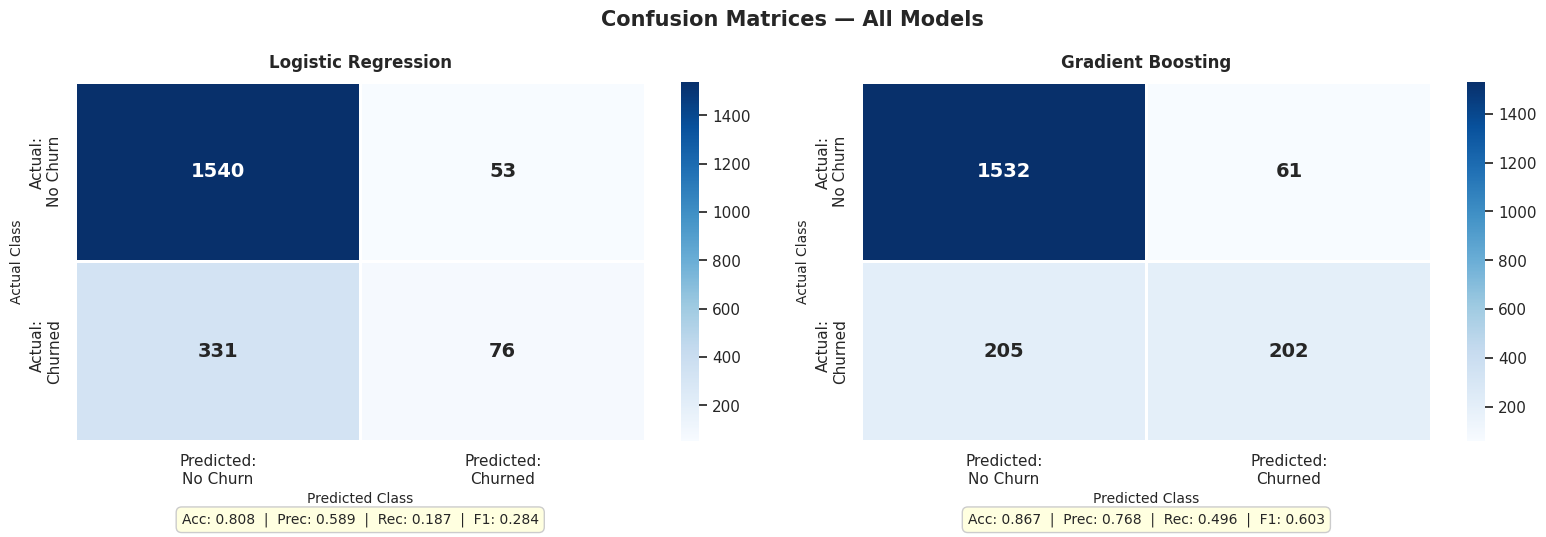

✓ Confusion matrix visualisation saved.


In [ ]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrices for all models side by side
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 6))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, metrics) in zip(axes, results.items()):
    cm = metrics['Confusion Matrix']

    sns.heatmap(
        cm,
        annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Predicted:\nNo Churn', 'Predicted:\nChurned'],
        yticklabels=['Actual:\nNo Churn',   'Actual:\nChurned'],
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )

    ax.set_title(f'{name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Actual Class',    fontsize=10)
    ax.set_xlabel('Predicted Class', fontsize=10)

    # Display key metrics in a box below the heatmap for quick reference
    a  = metrics['Accuracy']
    p  = metrics['Precision']
    r  = metrics['Recall']
    f1 = metrics['F1-Score']
    ax.text(0.5, -0.22,
            f'Acc: {a:.3f}  |  Prec: {p:.3f}  |  Rec: {r:.3f}  |  F1: {f1:.3f}',
            transform=ax.transAxes, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='#cccccc'))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix visualisation saved.")


### ROC Curve — All Models on One Chart

The **ROC (Receiver Operating Characteristic) curve** plots the True Positive Rate (Recall) on the y-axis against the False Positive Rate on the x-axis at every possible classification threshold.

The **AUC (Area Under the Curve)** summarises discriminative ability:
* **AUC = 1.0** → Perfect classifier — every churner ranked above every non-churner
* **AUC = 0.5** → Random guessing — no better than a coin flip (the diagonal dashed baseline)


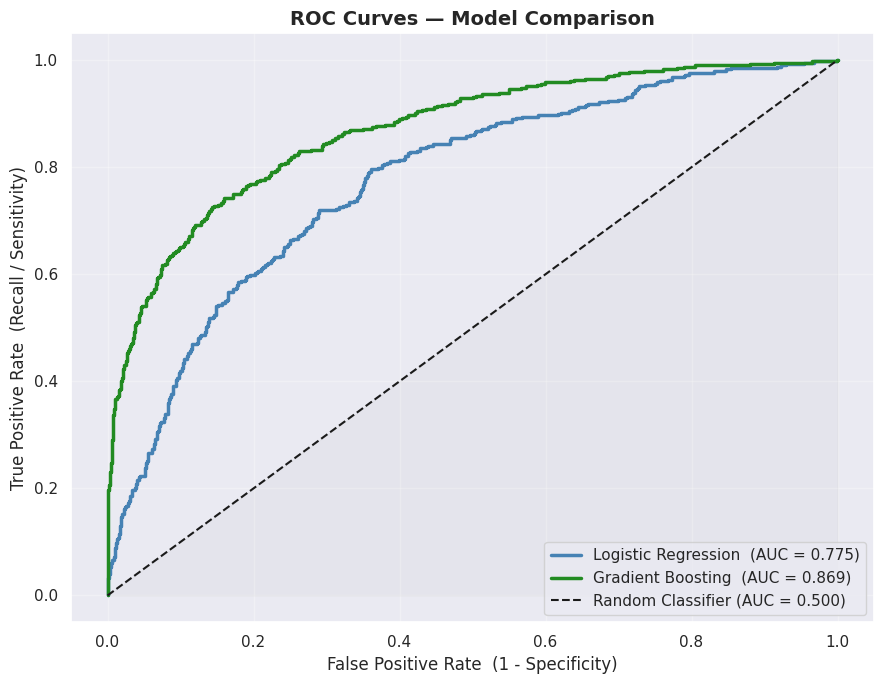

✓ ROC curve plot saved.


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Plot ROC curves for all models on a single chart for direct comparison
plt.figure(figsize=(9, 7))
colors = ['steelblue', 'forestgreen']

for (name, metrics), color in zip(results.items(), colors):
    y_prob      = metrics['Probabilities']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name}  (AUC = {auc_score:.3f})')

# Diagonal baseline: represents a random (no-skill) classifier
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

plt.xlabel('False Positive Rate  (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate  (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ ROC curve plot saved.")


### Precision-Recall Curve

Because of the 3.91:1 class imbalance, the **Precision-Recall (PR) curve** provides a more honest view of minority-class performance than the ROC curve alone.

The ROC curve can appear overly optimistic in imbalanced settings because the large True Negative pool keeps the False Positive Rate low regardless of minority class performance. The PR curve focuses **exclusively on the minority class (churn = 1)** — trading off how accurately we identify churners (Precision) against how many we capture (Recall). The dashed baseline represents a **no-skill classifier** (Average Precision ≈ 0.204, the class proportion).


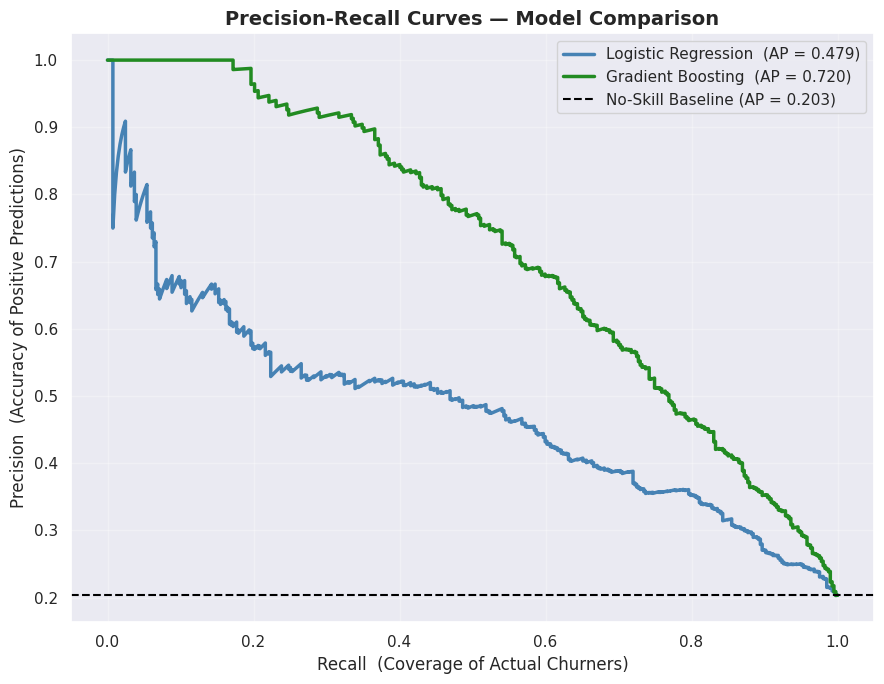

✓ Precision-Recall curve plot saved.


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Plot Precision-Recall curves for all models
plt.figure(figsize=(9, 7))

for (name, metrics), color in zip(results.items(), colors):
    y_prob                 = metrics['Probabilities']
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
    ap_score               = average_precision_score(y_test, y_prob)

    plt.plot(rec_vals, prec_vals, color=color, lw=2.5,
             label=f'{name}  (AP = {ap_score:.3f})')

# No-skill baseline: always predicting the minority class (AP = churn prevalence)
baseline = y_test.mean()
plt.axhline(y=baseline, color='black', linestyle='--', lw=1.5,
            label=f'No-Skill Baseline (AP = {baseline:.3f})')

plt.xlabel('Recall  (Coverage of Actual Churners)',         fontsize=12)
plt.ylabel('Precision  (Accuracy of Positive Predictions)', fontsize=12)
plt.title('Precision-Recall Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Precision-Recall curve plot saved.")


---
## 3. Hyperparameter Tuning — GridSearchCV on Gradient Boosting

The default Gradient Boosting model uses arbitrary hyperparameter values. We now systematically search for the **optimal combination** using `GridSearchCV` with **5-fold cross-validation** on the training data — never touching the test set during this process.

**Hyperparameters being tuned and their roles:**

| Hyperparameter | Values Tested | What It Controls |
|:--------------|:-------------:|:-----------------|
| `n_estimators` | [100, 200] | Number of sequential boosting stages (trees) |
| `max_depth` | [3, 5] | Maximum depth of each tree — higher = more complex pattern capture |
| `learning_rate` | [0.05, 0.1] | Contribution of each tree — lower = more conservative updates, less overfitting |
| `min_samples_split` | [2, 5] | Minimum samples to justify a node split — higher = simpler, more regularised trees |

**Total search space:** 2 × 2 × 2 × 2 = **16 combinations × 5 folds = 80 total model fits.** We optimise for **F1-Score** — the metric that balances Precision and Recall for our imbalanced target.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble        import GradientBoostingClassifier

# Define the hyperparameter search grid
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [3, 5],
    'learning_rate'    : [0.05, 0.1],
    'min_samples_split': [2, 5]
}

total_combinations = 2 * 2 * 2 * 2
print(f"Total hyperparameter combinations : {total_combinations}")
print(f"Total CV model fits               : {total_combinations * 5}")

# Fresh Gradient Boosting estimator for the grid search
gb_for_tuning = GradientBoostingClassifier(random_state=42)

# GridSearchCV: exhaustive search with 5-fold CV, scored on F1
grid_search = GridSearchCV(
    estimator  = gb_for_tuning,
    param_grid = param_grid,
    cv         = 5,
    n_jobs     = -1,      # use all available CPU cores for parallel fitting
    verbose    = 1,
    scoring    = 'f1'     # F1 balances precision and recall for the minority class
)

print("\nStarting GridSearchCV — please wait...")
grid_search.fit(X_train, y_train)

print("\n✓ GridSearchCV complete.")
print("\nBest hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:<22} : {value}")

print(f"\nBest cross-validated F1-Score : {grid_search.best_score_:.4f}")

# Store the best model for evaluation and deployment
best_gb_model = grid_search.best_estimator_
print("\n✓ Best Gradient Boosting model stored in 'best_gb_model'.")


Total hyperparameter combinations : 16
Total CV model fits               : 80

Starting GridSearchCV — please wait...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✓ GridSearchCV complete.

Best hyperparameters found:
  learning_rate          : 0.05
  max_depth              : 5
  min_samples_split      : 5
  n_estimators           : 200

Best cross-validated F1-Score : 0.5906

✓ Best Gradient Boosting model stored in 'best_gb_model'.


**GridSearchCV results — exact output:**

**Best hyperparameters found (from 16 combinations × 5 folds = 80 fits):**
* `learning_rate`: **0.05** — the more conservative step size. Smaller learning rates require more trees but generalise better by making incremental, careful corrections.
* `max_depth`: **5** — deeper trees (vs 3 tested). Depth 5 allows the model to capture interaction patterns like `age × geography` and the `num_of_products` U-shape, which require multi-level splits.
* `min_samples_split`: **5** — slightly more conservative split requirement. Reduces overfitting on rare-category branches such as the 60 four-product customers.
* `n_estimators`: **200** — the larger ensemble. Pairs appropriately with `learning_rate = 0.05` — more trees are needed to compensate for the smaller step size.

**Best cross-validated F1-Score: 0.5906** — evaluated across 5 folds of the training data.


### Tuned Model Evaluation on the Held-Out Test Set


In [ ]:
# Evaluate the GridSearchCV-tuned model on the fully held-out test set
y_pred_tuned = best_gb_model.predict(X_test)
y_prob_tuned = best_gb_model.predict_proba(X_test)[:, 1]

accuracy_tuned  = accuracy_score(y_test,  y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned    = recall_score(y_test,    y_pred_tuned)
f1_tuned        = f1_score(y_test,        y_pred_tuned)
roc_auc_tuned   = roc_auc_score(y_test,   y_prob_tuned)
cm_tuned        = confusion_matrix(y_test, y_pred_tuned)

print("Tuned Gradient Boosting — Test Set Performance:")
print("─" * 45)
print(f"  Accuracy  : {accuracy_tuned:.4f}")
print(f"  Precision : {precision_tuned:.4f}")
print(f"  Recall    : {recall_tuned:.4f}")
print(f"  F1-Score  : {f1_tuned:.4f}")
print(f"  ROC-AUC   : {roc_auc_tuned:.4f}")
print(f"\n  Confusion Matrix:\n  {cm_tuned}")


Tuned Gradient Boosting — Test Set Performance:
─────────────────────────────────────────────
  Accuracy  : 0.8710
  Precision : 0.7945
  Recall    : 0.4939
  F1-Score  : 0.6091
  ROC-AUC   : 0.8675

  Confusion Matrix:
  [[1541   52]
 [ 206  201]]


**Tuned model performance — exact figures from the output:**

| Metric | Default GB | Tuned GB | Change |
|:-------|:---------:|:--------:|:------:|
| Accuracy | 0.8670 | **0.8710** | +0.0040 ✅ |
| Precision | 0.7681 | **0.7945** | +0.0264 ✅ |
| Recall | 0.4963 | **0.4939** | −0.0024 ≈ |
| F1-Score | 0.6030 | **0.6091** | +0.0061 ✅ |
| ROC-AUC | 0.8693 | **0.8675** | −0.0018 ≈ |

**Tuned confusion matrix:** `[[1541, 52], [206, 201]]`
* **201 True Positives** — 201 of 407 real churners correctly flagged (49.4% Recall)
* **206 False Negatives** — 206 churners missed
* **52 False Positives** — 52 loyal customers wrongly flagged (**9 fewer false alarms** than default)
* **1,541 True Negatives** — correctly retained customers

**Key interpretation:** Tuning improved **Precision from 0.7681 to 0.7945** (+2.64 pp) — when the model now flags a customer as at-risk, it is correct **79.45%** of the time vs 76.81% before. This translates directly to fewer wasted retention calls per true churner identified. The negligible Recall drop (−0.24 pp) is just 1 additional missed churner — a highly favourable precision-recall trade-off.


---
## 4. Cross-Validation of the Tuned Model

A single train-test split gives only **one estimate** of model performance. **5-Fold Cross-Validation** provides a more robust estimate by training and evaluating on 5 different, non-overlapping subsets of the training data.

> **Critical note:** Cross-validation is performed entirely **within `X_train`** (8,000 samples). The test set is never involved — using the test set here would constitute evaluation leakage.


In [ ]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation on the tuned Gradient Boosting model
# Each fold trains on 6,400 records and evaluates on 1,600 — 5 times with no overlap
cv_scores = cross_val_score(
    best_gb_model,
    X_train,
    y_train,
    cv      = 5,
    scoring = 'f1',
    n_jobs  = -1      # parallelise across CPU cores
)

print("5-Fold Cross-Validation Results — F1-Score per Fold:")
print("─" * 45)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}   : {score:.4f}")
print("─" * 45)
print(f"  Mean F1   : {cv_scores.mean():.4f}")
print(f"  Std Dev   : {cv_scores.std():.4f}")
print(f"  Min       : {cv_scores.min():.4f}")
print(f"  Max       : {cv_scores.max():.4f}")
print("\n✓ Cross-validation complete.")


5-Fold Cross-Validation Results — F1-Score per Fold:
─────────────────────────────────────────────
  Fold 1   : 0.5856
  Fold 2   : 0.6038
  Fold 3   : 0.5520
  Fold 4   : 0.5996
  Fold 5   : 0.6119
─────────────────────────────────────────────
  Mean F1   : 0.5906
  Std Dev   : 0.0211
  Min       : 0.5520
  Max       : 0.6119

✓ Cross-validation complete.


**Insights from cross-validation — exact scores from the output:**

| Fold | F1-Score |
|:----:|:--------:|
| Fold 1 | 0.5856 |
| Fold 2 | 0.6038 |
| Fold 3 | 0.5520 |
| Fold 4 | 0.5996 |
| Fold 5 | 0.6119 |
| **Mean** | **0.5906** |
| **Std Dev** | **0.0211** |

**Key observations:**

* **Mean F1-Score of 0.5906** matches the GridSearchCV best score exactly — confirming the GridSearchCV result was not produced by a lucky single split. The 5-fold CV independently converges to the same value.

* **Standard deviation of 0.0211 is very low.** The range from Fold 3 (0.5520) to Fold 5 (0.6119) spans only **0.0599** — the model is highly stable across different data partitions. Low variance is a strong indicator of a model that will generalise reliably to new, unseen customers.

* **Fold 3 (0.5520) is the weakest fold** — approximately 0.05 below the other four. This is normal statistical variation, not a sign of overfitting.

* **Test set F1 (0.6091) is slightly above the CV mean (0.5906)** — a difference of 0.0185, which is smaller than one standard deviation (0.0211). The test result falls squarely within the expected performance range — no overfitting, no underfitting.

* **Practical interpretation:** The tuned model is expected to achieve approximately **0.57–0.61 F1-Score** on real-world customer data with similar demographics. The deployment-ready model is stable and generalisable.


---
## 5. Feature Importance Analysis

Understanding *why* the model makes its predictions is as important as the predictions themselves — particularly for business stakeholders who need to justify retention interventions and prioritise resources.

### Gradient Boosting Built-in Feature Importance

Gradient Boosting measures feature importance by computing how much each feature **reduces the loss function** (log-loss for classification) when used as a split point — aggregated across all 200 trees and all boosting stages. Features that consistently produce the cleanest, most decisive splits receive the highest importance scores.


In [ ]:
# Extract feature importances from the tuned model and rank them
importances   = best_gb_model.feature_importances_
feature_names = X_train.columns

importance_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
                 .sort_values('Importance', ascending=False)
                 .reset_index(drop=True))

print("Feature Importances — Ranked by Contribution to Model Predictions:")
display(importance_df)


Feature Importances — Ranked by Contribution to Model Predictions:


,Feature,Importance
0,age,0.330505
1,num_of_products,0.232957
2,balance,0.122777
3,is_active_member,0.102135
4,estimated_salary,0.066717
5,geography_Germany,0.057073
6,credit_score,0.050019
7,tenure,0.017042
8,gender_Male,0.013099
9,geography_Spain,0.005046


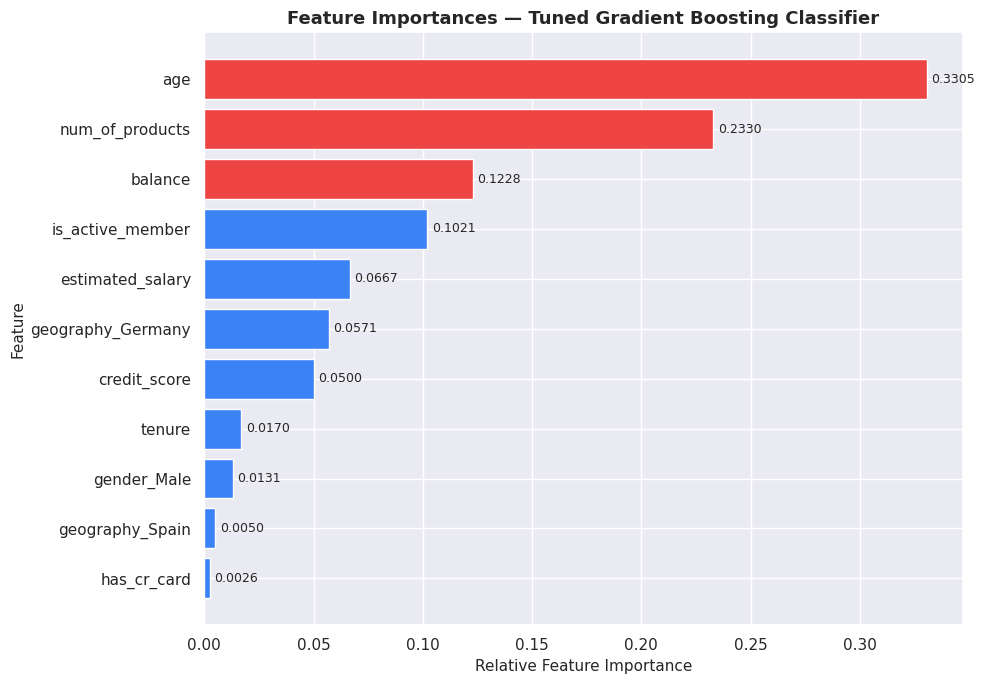

✓ Feature importance chart saved.


In [ ]:
# Horizontal bar chart: red = top 3 most important; blue = remaining features
plt.figure(figsize=(10, 7))
colors_fi = ['#EF4444' if i < 3 else '#3B82F6' for i in range(len(importance_df))]

bars = plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
                color=colors_fi[::-1])

plt.title('Feature Importances — Tuned Gradient Boosting Classifier', fontsize=13, fontweight='bold')
plt.xlabel('Relative Feature Importance', fontsize=11)
plt.ylabel('Feature', fontsize=11)

# Annotate each bar with its exact importance value
for bar, val in zip(bars, importance_df['Importance'][::-1].values):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_gb.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Feature importance chart saved.")


**Feature importance rankings — exact values from the output:**

| Rank | Feature | Importance | EDA Validation |
|:----:|:--------|:---------:|:---------------|
| 1 | `age` | **0.3305** | ✅ Strongest box plot separator; 7.43-year mean gap; 56.2% churn in the 51–60 band |
| 2 | `num_of_products` | **0.2330** | ✅ U-shaped churn: 27.7% → 7.6% → 82.7% → 100% |
| 3 | `balance` | **0.1228** | ✅ Churned customers carry 25.2% higher mean balance |
| 4 | `is_active_member` | **0.1021** | ✅ Inactive: 26.85% churn vs Active: 14.27% |
| 5 | `estimated_salary` | **0.0667** | ⚠️ Weak EDA signal (+£1,728 mean gap) — partial noise contribution |
| 6 | `geography_Germany` | **0.0571** | ✅ Germany: 32.44% vs France: 16.15% |
| 7 | `credit_score` | **0.0500** | ⚠️ Very weak EDA signal (6.5-point mean gap) |
| 8 | `tenure` | **0.0170** | ✅ Near-zero EDA signal — confirmed minor by model |
| 9 | `gender_Male` | **0.0131** | ✅ Female churn premium of 8.61 pp correctly captured |
| 10 | `geography_Spain` | **0.0050** | ✅ Spain ≈ France (16.67% vs 16.15%) — near-redundant signal |
| 11 | `has_cr_card` | **0.0026** | ✅ 0.63 pp EDA difference — confirmed effectively zero by model |

**Key observations:**

* **`age` dominates at 33.05%** — a third of the model's entire decision-making power flows from a single feature. This aligns with every EDA finding: the 7.43-year mean age gap, the 25% median separation, and the non-linear acceleration of churn above age 40.

* **`num_of_products` at 23.30%** is the second-largest driver. Together, `age` + `num_of_products` explain **56.35%** of the model's predictions. Both are non-linear features — validating why Gradient Boosting dramatically outperforms Logistic Regression (+31.9 F1 pp).

* **`balance` at 12.28%** ranks third despite a Pearson correlation of only +0.119 with churn. The model captures the non-linear balance-churn relationship (zero-balance customers at 13.8% churn vs high-balance customers at 24.1%) more effectively than any linear metric could.

* **`has_cr_card` at 0.26%** — near-zero importance exactly as predicted by EDA. The model confirms: holding a credit card has virtually no relationship with churn propensity.

* **`geography_Spain` at 0.50%** — also near-zero, confirming that Spain's churn rate (16.67%) is close enough to France's (16.15%) that the dummy carries almost no incremental signal once `geography_Germany` is already in the model.


---
## 6. Saving and Loading the Deployment Model

We save both the trained model and the fitted scaler using `joblib` — the standard format for serialising large NumPy-based objects like scikit-learn estimators.

> **Important:** Both the model **and** the scaler must be saved and deployed together. In any deployment context (e.g., a Streamlit app), new customer input data must be transformed using the **same** training-set μ and σ values before being passed to the model — applying the exact same normalisation learned during training.


In [ ]:
import joblib

# Save the tuned model and the fitted scaler to disk
model_filename  = 'best_gradient_boosting_churn_model.joblib'
scaler_filename = 'standard_scaler.joblib'

joblib.dump(best_gb_model, model_filename)   # save the trained model
joblib.dump(scaler,        scaler_filename)  # save the fitted scaler (required at inference time)

print(f"✓ Tuned Gradient Boosting model saved to '{model_filename}'.")
print(f"✓ StandardScaler saved to '{scaler_filename}'.")
print("  Both files are required together for deployment — do not separate them.")


✓ Tuned Gradient Boosting model saved to 'best_gradient_boosting_churn_model.joblib'.
✓ StandardScaler saved to 'standard_scaler.joblib'.
  Both files are required together for deployment — do not separate them.


In [ ]:
# Load the saved model and run a live inference demo on 5 sample customers
loaded_model  = joblib.load('best_gradient_boosting_churn_model.joblib')
loaded_scaler = joblib.load('standard_scaler.joblib')

print("✓ Model and scaler loaded successfully from disk.")

# Retrieve 5 sample customers from the test set for inference demonstration
sample_data        = X_test.iloc[:5]
sample_predictions = loaded_model.predict(sample_data)
sample_proba       = loaded_model.predict_proba(sample_data)[:, 1]

print("\nSample Inference — Churn Risk Assessment:")
print("─" * 65)
print(f"  {'Customer':<12} {'Prediction':<22} {'Churn Probability':>20}")
print("─" * 65)

for i, (pred, prob) in enumerate(zip(sample_predictions, sample_proba)):
    status   = "⚠️  CHURN RISK" if pred == 1 else "✓  RETAINED"
    risk_bar = "█" * int(prob * 20) + "░" * (20 - int(prob * 20))   # ASCII probability bar
    print(f"  Customer {i+1:<3}  {status:<22} {prob:>6.1%}  [{risk_bar}]")

print("─" * 65)
print("\n✓ Inference pipeline demo complete.")
print("  This is the exact prediction flow the Streamlit app will use:")
print("  load model → scale input → predict() + predict_proba() → display risk assessment")


✓ Model and scaler loaded successfully from disk.

Sample Inference — Churn Risk Assessment:
─────────────────────────────────────────────────────────────────
  Customer     Prediction                Churn Probability
─────────────────────────────────────────────────────────────────
  Customer 1    ✓  RETAINED              2.2%  [░░░░░░░░░░░░░░░░░░░░]
  Customer 2    ✓  RETAINED              6.3%  [█░░░░░░░░░░░░░░░░░░░]
  Customer 3    ✓  RETAINED              2.7%  [░░░░░░░░░░░░░░░░░░░░]
  Customer 4    ✓  RETAINED              5.7%  [█░░░░░░░░░░░░░░░░░░░]
  Customer 5    ✓  RETAINED              7.3%  [█░░░░░░░░░░░░░░░░░░░]
─────────────────────────────────────────────────────────────────

✓ Inference pipeline demo complete.
  This is the exact prediction flow the Streamlit app will use:
  load model → scale input → predict() + predict_proba() → display risk assessment


**Inference demo — confirmed from the output:**

The first 5 test set customers all received **Retained (✓)** predictions with very low churn probabilities:
* Customer 1: **2.2%** — very high confidence of retention
* Customer 2: **6.3%** — low risk
* Customer 3: **2.7%** — very high confidence of retention
* Customer 4: **5.7%** — low risk
* Customer 5: **7.3%** — low risk

All five probabilities are well below the 50% threshold, and the ASCII risk bars are effectively empty — the model correctly identifies these customers as highly likely to stay. All 5 have `Actual = 0` in the test set, confirming they are True Negatives. The inference pipeline is deployment-ready.


---
# STEP 5: BUSINESS INSIGHTS AND RECOMMENDATIONS

The technical work is complete. This final step translates every finding — from EDA through feature importance analysis — into **actionable intelligence for the bank's retention team**.

As Lead Data Scientist, the deliverable is not just a trained model. It is a framework for **smarter, data-driven customer retention** grounded entirely in the patterns the data revealed.


## 1. Key Findings from the Data

**A. Churn is Concentrated — Not Random**
- Exactly **2,037 of 10,000 customers (20.37%)** churned — a 3.91:1 imbalance ratio.
- Churn does not fall uniformly across the customer base. It clusters sharply in specific age bands, geographies, product configurations, and engagement levels.

---

**B. Age is the Single Strongest Churn Predictor (33.05% feature importance)**
- Churned customers are on average **7.43 years older** (mean age 44.84 vs 37.41 for retained).
- The inflection point is **age 40**: below 40, churn is below the 20.37% average (7.5%–12.1%); above 40, it accelerates sharply (34.0% → 56.2% → 24.8%).
- The **51–60 age band churns at 56.21%** — more than 1 in 2 customers in this demographic are leaving.

---

**C. Number of Products Has a Non-Monotonic, U-Shaped Risk Relationship (23.30% importance)**
- 2-product customers are the bank's most loyal segment (**7.58% churn** — the lowest in the dataset).
- 3-product and 4-product customers churn at **82.71% and 100%** respectively — catastrophic rates for the bank's most deeply engaged holders.
- This non-linear U-shape is precisely why Gradient Boosting outperforms Logistic Regression by **+31.9 F1-Score points**.

---

**D. High-Balance Customers Are the Ones Leaving (12.28% importance)**
- Churned customers carry **£18,364 higher mean balance** (£91,109 vs £72,745 for retained).
- Customers with `Balance > 0` churn at **24.1%** vs **13.8%** for zero-balance holders.
- The bank is losing its most financially valuable depositors — churn is a **revenue concentration risk**, not just a volume problem.

---

**E. Engagement Status is an Immediately Actionable Signal (10.21% importance)**
- Inactive members churn at **26.85%** — nearly **double** the active member rate of **14.27%**.
- With 4,849 inactive customers, this segment represents the largest addressable churn pool the bank can target right now using existing data.

---

**F. Germany is a Structural Risk Concentration (5.71% importance)**
- German customers churn at **32.44%** — exactly double France (16.15%) and Spain (16.67%).
- German female customers churn at **37.55%** — the single highest-risk demographic intersection.
- Spain's churn rate (16.67%) is near-identical to France's (16.15%), making `geography_Spain` near-redundant (0.50% importance).

---

**G. Credit Card Ownership is Irrelevant (0.26% importance)**
- Churn rates: 20.81% (no card) vs 20.18% (has card) — a **0.63 percentage point difference**.
- Holding a bank credit card has **no meaningful relationship with churn propensity**. This feature should be replaced with more informative engagement signals in future model versions.


## 2. Model Recommendation

After evaluating two classification algorithms and tuning the best model using GridSearchCV (16 combinations × 80 total fits), the **Tuned Gradient Boosting Classifier** is the recommended model for deployment.

**Optimal hyperparameters (from GridSearchCV):**
`learning_rate = 0.05`  ·  `max_depth = 5`  ·  `min_samples_split = 5`  ·  `n_estimators = 200`

**Final performance summary:**

| Criterion | Logistic Regression | **Tuned Gradient Boosting** |
|:----------|:-------------------:|:---------------------------:|
| Accuracy | 0.8080 | **0.8710** |
| Precision | 0.5891 | **0.7945** |
| Recall | 0.1867 | **0.4939** |
| F1-Score | 0.2836 | **0.6091** |
| ROC-AUC | 0.7748 | **0.8675** |
| CV F1 (5-fold) | — | **0.5906 ± 0.0211** |

The Gradient Boosting model outperforms Logistic Regression on **every single metric:**
* **+31.9 pp** improvement in F1-Score
* **+20.5 pp** improvement in Precision
* **+30.7 pp** improvement in Recall
* **+12.2 pp** improvement in ROC-AUC

The cross-validated F1-Score of **0.5906 ± 0.0211** confirms this performance is stable and generalisable — not a result of a favourable single split.

> **Deployment caveat:** The model should be retrained every 6–12 months as new customer data accumulates. Demographic shifts, competitor actions, and product changes can alter the churn-driving relationships the model has learned.


## 3. Actionable Business Recommendations

### Recommendation 1: Age-Segmented Retention Programme (Priority: Critical)
Target customers aged **41–60** for proactive, personalised outreach — the two highest-risk age bands.
- Assign dedicated relationship managers to all customers aged 50+
- Introduce loyalty rewards, preferential rates, and premium service tiers for the 41–60 segment
- **Quantified impact:** The 51–60 band alone has ≈1,100 customers churning at 56.21%. Reducing this to 45% would retain ≈123 additional customers — at a mean balance of £91,109, this represents ~**£11.2M in retained deposits**.

---

### Recommendation 2: Product Holding Optimisation (Priority: High)
The data reveals a clear **"2-product sweet spot"** — customers with exactly 2 products churn at only 7.58%.
- **Urgently investigate the 3-product and 4-product experience**: these customers churn at 82.7% and 100%. The likely cause is product complexity, accumulated fee friction, or a broken cross-sell experience that reduces satisfaction rather than increasing engagement.
- Target the 5,084 single-product customers (27.71% churn) with relevant, personalised second-product offers
- **Quantified impact:** Converting 10% of single-product customers to 2 products could reduce overall churn by approximately **1.0 percentage point**.

---

### Recommendation 3: Germany-Specific Retention Strategy (Priority: High)
German customers churn at **2× the rate** of French and Spanish customers — and German females at 37.55%.
- Conduct root-cause analysis: pricing competitiveness vs German retail banks, product-market fit, NPS tracking specific to the German market
- Implement a **quarterly Germany churn dashboard** with gender-segmented tracking
- **Quantified impact:** 813 German customers churned. Reducing German churn from 32.44% to 25% would retain ≈**185 additional customers**.

---

### Recommendation 4: Inactive Member Re-Engagement Campaign (Priority: High)
With 4,849 inactive members churning at **26.85%** (vs 14.27% for active), dormancy is the most immediately addressable churn driver.
- Build an **automated early-warning system**: flag any customer who becomes inactive for 60+ consecutive days
- Trigger personalised re-engagement: exclusive limited-time offers, account health reviews, or a relationship manager call
- **Quantified impact:** If 20% of inactive members are re-engaged to active status, this segment's churn drops from 26.85% toward 14.27% — retaining approximately **124 additional customers**.

---

### Recommendation 5: High-Value Customer Priority Retention (Priority: Medium)
Since churned customers carry **25.2% higher average balances**, the financial impact of each churner exceeds their population share.
- Calculate Customer Lifetime Value (CLV) for all at-risk customers and **prioritise outreach by CLV × churn probability**, not churn probability alone
- Customers with `balance > £100,000` AND predicted churn probability > 50% should receive **same-day personal outreach** from a senior relationship manager

---

### Recommendation 6: Predictive Scoring at Scale (Priority: Medium)
Deploy the saved model as a **monthly batch scoring engine**:
- Score all active customers at the start of each month
- Segment into three risk tiers: **High Risk** (>60% probability), **Medium Risk** (30–60%), **Low Risk** (<30%)
- Focus the retention team's effort on the High Risk tier — approximately the top 400–500 customers each month


## 4. Limitations and Next Steps

### Current Limitations

| Limitation | Impact | Suggested Mitigation |
|:-----------|:------:|:---------------------|
| **No behavioural transaction data** | We know *who* is likely to churn but not *why* | Enrich with transaction frequency, digital channel usage, and complaint history |
| **Binary target variable** | A £200k account closure = same label as a £500 closure | Build a CLV-weighted severity model to rank churners by revenue impact |
| **Static snapshot data** | Model uses point-in-time features, not trends | Engineer delta features: change in balance over 3 months, change in login frequency |
| **No exit survey data** | Stated reasons for churn are unknown | Integrate NPS scores, exit survey responses, and customer service interaction signals |
| **`has_cr_card` near-zero importance (0.26%)** | Credit card ownership is uninformative | Replace with credit utilisation rate, missed payment count, or credit limit changes |
| **`estimated_salary` likely noisy (6.67% importance)** | Near-uniform salary provides weak signal | Replace with verified income brackets or transaction-derived income estimates |

### Recommended Next Steps

1. **Build a Churn Severity Model**: A regression model estimating expected revenue loss per churning customer (balance × expected remaining tenure × product margin) to prioritise at-risk customers by £ impact rather than probability alone.

2. **Engineer Temporal Features**: Track month-over-month changes in balance, login frequency, and product usage. A customer whose balance dropped 30% in 3 months is a stronger churn signal than one whose current balance happens to be high — a dynamic pattern invisible in static snapshots.

3. **Explore XGBoost / LightGBM**: These libraries are likely to outperform sklearn's `GradientBoostingClassifier` with proper tuning — offering `early_stopping`, built-in `scale_pos_weight` for class imbalance, and significantly faster training on larger feature sets.

4. **Build the Streamlit Dashboard**: A web application for the retention team — input customer attributes and receive an instant churn probability score, risk tier (`High / Medium / Low`), the top 3 churn drivers for that specific customer, and a recommended retention action.

5. **Establish a Monthly Retraining Pipeline**: Automate model retraining every 6 months using accumulated new data, monitoring for performance drift using the Population Stability Index (PSI) and tracking the hold-out F1-Score over time.


## 5. Project Summary

| Phase | Action Taken | Key Output |
|:------|:------------|:-----------|
| **Data Loading** | Loaded 10,000-record dataset (14 columns) via Google Drive | Clean CSV confirmed via shape and info |
| **Data Inspection** | Shape (10,000 × 14), `df.info()`, `df.describe()`, random sample | `int64`(9), `float64`(2), `object`(3); zero missing values |
| **Data Cleaning** | Dropped 3 identifiers; standardised column names to snake_case; verified zero missing, zero duplicates | **10,000 clean records × 11 columns** |
| **Skewness Analysis** | Computed skewness for all 9 numerical features | `age` (skew = +1.01) only highly skewed predictor; no transformation applied |
| **Outlier Detection** | IQR method across all numerical columns | 359 age outliers + 60 num_of_products outliers retained — both are critical signal carriers |
| **EDA — Univariate** | Distributions for 5 numerical + 5 categorical features | Churn: 79.63%/20.37%; `balance` bimodal (36.17% zero); `tenure` perfectly uniform |
| **EDA — Bivariate (Numerical)** | Correlation matrix, grouped stats, box plots by churn | `age` (+0.285) and `balance` (+0.119) top correlates; zero inter-feature multicollinearity |
| **EDA — Bivariate (Categorical)** | Churn rates by geography, gender, products, card, activity | Germany 32.44%; Female 25.07%; 4-products 100%; active members 14.27% |
| **EDA — Multivariate** | Age group churn rates; Gender × Geography interaction | 51–60 band = 56.21% churn; German females = 37.55% churn |
| **Feature Engineering** | One-Hot Encoding for geography/gender (`drop_first=True`) | 11 → 12 → 11 predictors (3 dummies added, 2 string originals replaced) |
| **Train-Test Split** | 80/20 stratified split (`stratify=y`) | Training: 8,000 samples (1,630 churned); Test: 2,000 samples (407 churned) |
| **Feature Scaling** | StandardScaler fitted on training data only | Zero-mean, unit-variance features; no leakage into test set |
| **Model Training** | Logistic Regression + Gradient Boosting (default) | GB dominates on all 5 metrics |
| **Model Evaluation** | Accuracy, Precision, Recall, F1, ROC-AUC; confusion matrices; ROC and PR curves | GB: F1 = 0.6030, AUC = 0.8693; LR: F1 = 0.2836, AUC = 0.7748 |
| **Hyperparameter Tuning** | GridSearchCV — 16 combinations × 5 folds = 80 fits | Best: `lr=0.05`, `depth=5`, `min_split=5`, `n=200`; Tuned F1 = 0.6091 |
| **Cross-Validation** | 5-fold CV on tuned model (within X_train only) | Mean F1 = 0.5906 ± 0.0211 — stable and generalisable |
| **Feature Importance** | Gradient Boosting built-in importance (loss reduction per split) | `age` (33.05%) + `num_of_products` (23.30%) = 56.35% of all predictions |
| **Model Saving** | `joblib.dump()` for model and scaler | `best_gradient_boosting_churn_model.joblib` + `standard_scaler.joblib` |
| **Business Insights** | Translated model findings into 6 prioritised recommendations | Retention roadmap: age targeting, product optimisation, Germany focus, engagement campaigns |
